# Метамодель-арбитр: JSON → итоговый сигнал

Рабочая копия общего командного pipeline в директории Александра.

Ноутбук показывает всю итоговую связку:

`данные → rule/ML-движки → унифицированные записи → метамодель-арбитр → финальные события`.

Основной предмет дальнейших экспериментов — секции 5–6: обучение арбитра и сравнение итогового lift. Ноутбук использует общие модули из `src`, поэтому запускается из клонированного репозитория.

In [1]:
from datetime import date
from pathlib import Path
import json
import sys

import pandas as pd

# Ноутбук может быть запущен как из корня репозитория, так и из
# research/aleksandr/notebooks. Ищем ближайшего родителя с общей папкой src.
WORKING_DIRECTORY = Path.cwd().resolve()
candidate_roots = (WORKING_DIRECTORY, *WORKING_DIRECTORY.parents)
PROJECT_ROOT = next((root for root in candidate_roots if (root / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    checked = '\\n'.join(f'  - {root}' for root in candidate_roots)
    raise RuntimeError(
        'Не найден корень репозитория с папкой src. Проверенные пути:\\n'
        + checked
    )

SRC_DIR = PROJECT_ROOT / 'src'
required_scripts = (
    'production_pipeline.py', 'production_config.py', 'meta_model.py',
    'signal_contract.py', 'ml_backtest.py',
)
missing_scripts = [name for name in required_scripts if not (SRC_DIR / name).is_file()]
if missing_scripts:
    raise RuntimeError(f'В {SRC_DIR} не найдены скрипты: {missing_scripts}')

# Для импортов вида `from src...` в sys.path нужен корень репозитория.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Корень проекта: {PROJECT_ROOT}')
print(f'Общие скрипты: {SRC_DIR}')

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.features import build_features
from src.market_data import build_daily_market_panel
from src.meta_model import (
    build_meta_candidates, fit_logistic_meta_model, logistic_meta_model,
    run_meta_model,
)
from src.outcomes import add_future_outcomes
from src.production_config import (
    FIXED_INDICATORS, INDICATOR_SPACES, RULE_MIN_SIGNALS_PER_WEEK,
    ML_CONFIG, ML_FEATURE_NAMES, ML_MIN_SIGNALS_PER_WEEK,
    ML_MODEL_TYPE, ML_RETRAIN_MONTHS, ML_VALIDATION_MONTHS,
    PRODUCTION_CURRENCIES,
    PRODUCTION_HORIZONS, PRODUCTION_TARGET_FAMILIES, TRAIN_WINDOW_MONTHS,
    fixed_indicator_registry,
)
from src.production_pipeline import (
    engine_state_registry, filter_signal, get_signal, initialize_engine_states,
    replay_engine_signals, save_engine_states,
)
from src.signal_backtest import backtest_signal_stream, build_evaluation_universe
from src.visualization import plot_benefit_distribution, plot_oos_uplift, plot_signal_series
from src.targets import build_targets

START_DATE = date(2020, 1, 1)
END_DATE = date.today()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'cbr'

# Base OOS начинается в 2022. Meta train заканчивается до 2024,
# а финальный backtest всей связки начинается в 2025.
BASE_OOS_START = pd.Timestamp('2022-01-01')
META_TRAIN_END = pd.Timestamp('2024-01-01')
FINAL_BACKTEST_START = pd.Timestamp('2025-01-01')
META_VALIDATION_MONTHS = 12
META_MIN_SIGNALS_PER_WEEK = 1.0
META_MAX_SIGNALS_PER_WEEK = 2.0

Корень проекта: /Users/aleksandr/PycharmProjects/huck/AI_Product_Hack_trigger_model
Общие скрипты: /Users/aleksandr/PycharmProjects/huck/AI_Product_Hack_trigger_model/src


## 1. Данные, causal features и targets

Features строки используют только сведения, доступные к её `available_at`. Future outcomes и targets нужны для исторического обучения и оценки; они не входят в JSON сигнала.

In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE,
    end_date=END_DATE,
    currencies=CURRENCIES,
    raw_dir=RAW_DIR,
)
rates = (
    cbr_history.pivot(index='available_at', columns='currency', values='normalized_rate')
    .reindex(columns=list(CURRENCIES))
    .sort_index()
)
rates.columns.name = None
market_panel = build_daily_market_panel(rates)
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=PRODUCTION_HORIZONS)
dataset, target_registry = build_targets(outcomes, horizons=PRODUCTION_HORIZONS)
scoring_data = dataset.loc[
    dataset['is_update_day'] & dataset['currency'].isin(PRODUCTION_CURRENCIES)
].copy()

pd.DataFrame({
    'first_available_at': [scoring_data['available_at'].min()],
    'last_available_at': [scoring_data['available_at'].max()],
    'rows': [len(scoring_data)],
})

,first_available_at,last_available_at,rows
0,2020-01-02,2026-09-05,8220


## 2. Реестр движков

Создаётся по одному rule- и одному ML-движку для каждой `currency × target_family × horizon`. Пустое состояние знает, когда впервые обучиться; после обучения в нём находятся конкретное правило либо веса модели, версия, даты train и следующий срок обновления.

In [3]:
production_rule_registry = fixed_indicator_registry()
states = initialize_engine_states(
    rule_configurations=FIXED_INDICATORS,
    target_registry=target_registry,
    currencies=PRODUCTION_CURRENCIES,
    target_families=PRODUCTION_TARGET_FAMILIES,
    first_score_date=BASE_OOS_START,
    train_months=TRAIN_WINDOW_MONTHS,
    ml_feature_names=ML_FEATURE_NAMES,
    ml_model_type=ML_MODEL_TYPE,
    ml_retrain_months=ML_RETRAIN_MONTHS,
)

assert len(states) == 2 * len(PRODUCTION_CURRENCIES) * len(PRODUCTION_TARGET_FAMILIES) * len(PRODUCTION_HORIZONS)
production_rule_registry

,currency,scenario,target_family,target,horizon,indicator,parameter_variants,retrain_months
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,480,3
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,360,3
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,momentum_down__OR__trend_down,120,6
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,trend_down,6,3
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down__OR__momentum_up,400,3
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,480,3
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,momentum_down,20,3
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,momentum_down,20,3
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,down_streak__OR__trend_down,24,3
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down__OR__up_streak,80,12


## 3. Ежедневный исторический replay базовых движков

Для каждой даты выполняется один и тот же порядок:

1. `update_models_if_due` переобучает только просроченные движки и только на уже созревших targets из прошлого.
2. `get_signal` возвращает JSON-совместимый score всех движков, включая `signal=false` и технический статус.
3. Результатом является только неизменяемый `raw_signal_stream`; метамодель запускается отдельным этапом ниже.

Никакие итоговые метрики внутри этого цикла не оптимизируются.

In [4]:
replay = replay_engine_signals(
    scoring_data,
    states=states,
    first_score_date=BASE_OOS_START,
    indicator_spaces=INDICATOR_SPACES,
    rule_min_signals_per_week=RULE_MIN_SIGNALS_PER_WEEK,
    ml_validation_months=ML_VALIDATION_MONTHS,
    ml_min_signals_per_week=ML_MIN_SIGNALS_PER_WEEK,
    ml_model_type=ML_MODEL_TYPE,
    ml_model_config=ML_CONFIG,
)

## 4. Техническое состояние после replay

Это не таблица качества. Она отвечает только на эксплуатационные вопросы: какой артефакт сейчас активен, на каких зрелых данных обучен и когда должен обновиться. `training_audit` позволяет проверить, что обновления действительно происходили по заданному cadence.

In [5]:
current_engine_states = engine_state_registry(replay.states)
current_engine_states

,engine_id,engine_type,currency,target_family,target,horizon,architecture,train_months,model_version,configuration_version,trained_at,trained_through,next_retrain_at,last_retrain_attempt_at,last_retrain_error,confidence,confidence_support,ready
0,ml:AMD:G0:h1,ml,AMD,G0,target_g0_exact_min_h1d,1,hist_gradient_boosting,24,d71a00415f2229a8,56b759f68942ca16,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.577236,123,True
1,ml:AMD:G0:h3,ml,AMD,G0,target_g0_exact_min_h3d,3,hist_gradient_boosting,24,7365cc2fdad39c51,56b759f68942ca16,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.297030,101,True
2,ml:AMD:G0:h5,ml,AMD,G0,target_g0_exact_min_h5d,5,hist_gradient_boosting,24,78577a77ccb64a57,56b759f68942ca16,2026-01-01,2025-12-26,2027-01-01,2026-01-01,None,0.220000,100,True
3,ml:AMD:G0:h10,ml,AMD,G0,target_g0_exact_min_h10d,10,hist_gradient_boosting,24,2f4030bb8ccaafb9,56b759f68942ca16,2026-01-01,2025-12-21,2027-01-01,2026-01-01,None,0.131313,99,True
4,ml:AMD:G0:h20,ml,AMD,G0,target_g0_exact_min_h20d,20,hist_gradient_boosting,24,6028204466bbde20,56b759f68942ca16,2026-01-14,2025-12-24,2027-01-12,2026-01-14,None,0.059406,101,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,rule:UZS:W1:h1,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h1d,1,level_low__OR__high_volatility,24,66b3eb85ee2589f4,54c0529c2c73685a,2026-07-01,2026-06-28,2027-01-01,2026-07-01,None,0.088106,227,True
96,rule:UZS:W1:h3,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h3d,3,level_low__OR__high_volatility,24,b35f0f237633f969,54c0529c2c73685a,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.196172,209,True
97,rule:UZS:W1:h5,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h5d,5,level_low__OR__high_volatility,24,c4e023a841e4e8da,54c0529c2c73685a,2026-01-01,2025-12-26,2027-01-01,2026-01-01,None,0.236715,207,True
98,rule:UZS:W1:h10,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h10d,10,level_low__OR__high_volatility,24,37f2467cce84c7db,54c0529c2c73685a,2026-07-01,2026-06-20,2026-10-01,2026-07-01,None,0.276699,206,True


In [6]:
replay.training_audit[[
    'as_of', 'engine_id', 'fitted', 'trained_through', 'next_retrain_at'
]].tail(20)

,as_of,engine_id,fitted,trained_through,next_retrain_at
2012,2026-07-01,rule:UZS:G0:h5,True,2026-06-25,2026-10-01
2013,2026-07-01,rule:UZS:G0:h10,True,2026-06-20,2026-10-01
2014,2026-07-01,rule:UZS:G0:h20,True,2026-06-10,2026-10-01
2015,2026-07-01,rule:AMD:W1:h3,True,2026-06-27,2026-10-01
2016,2026-07-01,rule:AMD:W1:h10,True,2026-06-20,2027-01-01
2017,2026-07-01,rule:AMD:W1:h20,True,2026-06-10,2026-10-01
2018,2026-07-01,rule:KGS:W1:h1,True,2026-06-28,2026-10-01
2019,2026-07-01,rule:KGS:W1:h3,True,2026-06-27,2026-10-01
2020,2026-07-01,rule:KGS:W1:h5,True,2026-06-25,2026-10-01
2021,2026-07-01,rule:KGS:W1:h10,True,2026-06-20,2026-10-01


## 5. Логистическая метамодель

Метамодель получает только raw OOS-предикты базовых движков. Она обучается на OOS-кандидатах 2022–2023, использует 2023 как внутреннее validation-окно для выбора единого probability threshold, затем применяется к финальному потоку с `2025-01-01`. Базовые сигналы при этом не переобучаются и не изменяются.

In [7]:
raw_signal_stream = replay.raw_signals.copy()
raw_signal_stream['available_at'] = pd.to_datetime(raw_signal_stream['available_at'])

all_evaluation_universe = build_evaluation_universe(
    scoring_data,
    target_registry=target_registry,
    target_families=PRODUCTION_TARGET_FAMILIES,
    currencies=PRODUCTION_CURRENCIES,
    start_date=BASE_OOS_START,
)
meta_candidates = build_meta_candidates(raw_signal_stream)
meta_keys = ['available_at', 'currency', 'scenario', 'target_family', 'target', 'horizon']
meta_training_data = meta_candidates.merge(
    all_evaluation_universe[meta_keys + ['target_value']],
    on=meta_keys, how='left', validate='many_to_one',
).dropna(subset=['target_value'])

fitted_meta_model = fit_logistic_meta_model(
    meta_training_data,
    train_end=META_TRAIN_END,
    validation_months=META_VALIDATION_MONTHS,
    min_signals_per_week=META_MIN_SIGNALS_PER_WEEK,
    max_signals_per_week=META_MAX_SIGNALS_PER_WEEK,
)

final_raw_signal_stream = raw_signal_stream.loc[
    raw_signal_stream['available_at'].ge(FINAL_BACKTEST_START)
].copy()
final_signal_stream = run_meta_model(
    final_raw_signal_stream,
    meta_model=logistic_meta_model,
    config=fitted_meta_model,
)

# Отдельный production-style вызов для последней даты: raw JSON → filter JSON.
latest_date = raw_signal_stream['available_at'].max()
latest_raw_vector = raw_signal_stream.loc[
    raw_signal_stream['available_at'].eq(latest_date)
].to_dict(orient='records')
latest_filtered_events = filter_signal(
    latest_raw_vector,
    meta_model=logistic_meta_model,
    meta_config=fitted_meta_model,
)
print(f'Raw engine scores: {len(latest_raw_vector)}')
print(f'Filtered events: {len(latest_filtered_events)}')

meta_model_summary = pd.DataFrame([{
    'trained_at': fitted_meta_model.trained_at,
    'trained_through': fitted_meta_model.trained_through,
    'validation_start': fitted_meta_model.validation_start,
    'validation_end': fitted_meta_model.validation_end,
    'threshold': fitted_meta_model.threshold,
    'validation_precision': fitted_meta_model.validation_precision,
    'validation_lift': fitted_meta_model.validation_lift,
    'validation_signals_per_week': fitted_meta_model.validation_signals_per_week,
}])
meta_model_summary

Raw engine scores: 100
Filtered events: 3


,trained_at,trained_through,validation_start,validation_end,threshold,validation_precision,validation_lift,validation_signals_per_week
0,2024-01-01,2023-12-30,2023-01-01,2024-01-01,0.51728,0.533769,3.117318,8.826923


### 5.1. Сохранение входного и итогового JSON

Сохраняются два файла за последнюю доступную дату: полный вектор оценок базовых движков и события, прошедшие метамодель-арбитр. Папка `outputs` исследовательская и не добавляется в Git.

In [8]:
JSON_OUTPUT_DIR = (
    PROJECT_ROOT
    / 'research'
    / 'aleksandr'
    / 'outputs'
    / 'json'
)
JSON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if pd.isna(latest_date):
    raise RuntimeError('Нельзя сохранить JSON: поток базовых сигналов пуст')

date_label = pd.Timestamp(latest_date).strftime('%Y-%m-%d')
raw_json_path = JSON_OUTPUT_DIR / f'raw_signals_{date_label}.json'
final_json_path = JSON_OUTPUT_DIR / f'final_events_{date_label}.json'

with raw_json_path.open('w', encoding='utf-8') as file:
    json.dump(
        latest_raw_vector,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

with final_json_path.open('w', encoding='utf-8') as file:
    json.dump(
        latest_filtered_events,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print(f'Входной JSON: {raw_json_path}')
print(f'Записей базовых движков: {len(latest_raw_vector)}')
print(f'Итоговый JSON: {final_json_path}')
print(f'Событий после арбитра: {len(latest_filtered_events)}')


Входной JSON: /Users/aleksandr/PycharmProjects/huck/AI_Product_Hack_trigger_model/research/aleksandr/outputs/json/raw_signals_2026-09-05.json
Записей базовых движков: 100
Итоговый JSON: /Users/aleksandr/PycharmProjects/huck/AI_Product_Hack_trigger_model/research/aleksandr/outputs/json/final_events_2026-09-05.json
Событий после арбитра: 3


## 6. Единственная итоговая оценка — после метамодели

`signal_backtest_summary` считает результаты конечных событий логистической метамодели начиная с `FINAL_BACKTEST_START = 2025-01-01`. В отчёте ровно 65 строк: 5 по валютам, 25 по валютам и горизонтам, 50 по валютам, горизонтам и target family. Промежуточные rule/ML scores и validation-метрики не являются финальным backtest.

In [9]:
evaluation_universe = build_evaluation_universe(
    scoring_data,
    target_registry=target_registry,
    target_families=PRODUCTION_TARGET_FAMILIES,
    currencies=PRODUCTION_CURRENCIES,
    start_date=FINAL_BACKTEST_START,
)
signal_backtest_summary, signal_backtest_rows = backtest_signal_stream(
    final_signal_stream,
    evaluation_universe=evaluation_universe,
)
signal_backtest_summary

,scope,currency,horizon,target_family,observations,positive_count,signal_count,true_positive,false_positive,precision,random_precision,lift,calendar_weeks,signals_per_week,mean_benefit_bps,positive_benefit_rate
0,currency,AMD,ALL,ALL,4050,425,175,92,83,0.525714,0.104938,5.009748,86.000000,2.034884,28.042981,0.788571
1,currency,KGS,ALL,ALL,4050,416,194,96,98,0.494845,0.102716,4.817605,86.000000,2.255814,20.663339,0.773196
2,currency,KZT,ALL,ALL,4050,426,280,145,135,0.517857,0.105185,4.923290,86.000000,3.255814,41.401856,0.817857
3,currency,TJS,ALL,ALL,4050,399,192,94,98,0.489583,0.098519,4.969455,86.000000,2.232558,44.688470,0.807292
4,currency,UZS,ALL,ALL,4050,435,221,109,112,0.493213,0.107407,4.591980,86.000000,2.569767,43.330985,0.828054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,currency+horizon+target_family,UZS,5,W1,407,48,0,0,0,0.000000,0.117936,0.000000,85.285714,0.000000,NaN,0.000000
76,currency+horizon+target_family,UZS,10,G0,403,16,0,0,0,0.000000,0.039702,0.000000,84.714286,0.000000,NaN,0.000000
77,currency+horizon+target_family,UZS,10,W1,403,50,20,6,14,0.300000,0.124069,2.418000,84.714286,0.236088,83.690438,0.900000
78,currency+horizon+target_family,UZS,20,G0,397,9,0,0,0,0.000000,0.022670,0.000000,83.285714,0.000000,NaN,0.000000


## 7. Сравнение разных арбитров

Все варианты получают одни и те же OOS-оценки rule/ML-движков. Обучение выполняется на периоде до 2023 года, порог выбирается только на validation 2023 года, затем модель переобучается на всех зрелых кандидатах до 2024 года. Финальный период с 2025 года используется только для сравнения и не участвует в подборе порогов.

Сравниваются три простых арбитра (`любой кандидат`, `согласие rule и ML`, `фильтр по confidence`) и три обучаемых (`Logistic Regression`, `HistGradientBoosting`, `ExtraTrees`). Частота в таблице указана в среднем на одну валюту.

In [10]:
import hashlib
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.meta_model import (
    LOGISTIC_CATEGORICAL_FEATURES,
    LOGISTIC_FEATURES,
    LOGISTIC_NUMERIC_FEATURES,
    META_GROUP_COLUMNS,
)


def meta_periods(labelled_candidates, train_end, validation_months):
    """Одинаковый временной split и одинаковая проверка зрелости target."""
    end = pd.Timestamp(train_end)
    validation_start = end - pd.DateOffset(months=validation_months)
    data = labelled_candidates.copy()
    dates = pd.to_datetime(data['available_at'])
    mature = dates.add(pd.to_timedelta(data['horizon'], unit='D')).lt(end)

    fit = data.loc[dates.lt(validation_start) & mature].copy()
    validation = data.loc[
        dates.ge(validation_start) & dates.lt(end) & mature
    ].copy()
    training = data.loc[dates.lt(end) & mature].copy()

    if fit.empty or validation.empty or training.empty:
        raise RuntimeError('Для сравнения арбитров не хватает train/validation данных')
    if fit['target_value'].nunique() < 2 or training['target_value'].nunique() < 2:
        raise RuntimeError('В обучающей выборке арбитра присутствует только один класс')
    return fit, validation, training


def period_weeks(dates):
    dates = pd.to_datetime(dates)
    return max((dates.max() - dates.min()).days + 1, 1) / 7


def threshold_metrics(data, scores, threshold):
    y = data['target_value'].to_numpy(dtype=bool)
    prediction = np.asarray(scores, dtype=float) >= float(threshold)
    signal_count = int(prediction.sum())
    true_positive = int((prediction & y).sum())
    precision = true_positive / signal_count if signal_count else 0.0
    baseline = float(y.mean()) if len(y) else 0.0
    return {
        'precision': precision,
        'baseline': baseline,
        'lift': precision / baseline if baseline else 0.0,
        'signal_count': signal_count,
        'true_positive': true_positive,
        'signals_per_week': signal_count / period_weeks(data['available_at']),
    }


def frequency_by_currency(data, prediction):
    prediction = np.asarray(prediction, dtype=bool)
    values = {}
    for currency, group in data.groupby('currency', sort=True):
        positions = data.index.get_indexer(group.index)
        values[str(currency)] = float(
            prediction[positions].sum() / period_weeks(group['available_at'])
        )
    return values


def choose_arbiter_threshold(
    validation,
    scores,
    min_signals_per_week=META_MIN_SIGNALS_PER_WEEK,
    max_signals_per_week=META_MAX_SIGNALS_PER_WEEK,
):
    """Выбираем порог по validation: высокий lift при частоте 1–2 на валюту."""
    scores = np.asarray(scores, dtype=float)
    thresholds = np.unique(np.r_[0.5, scores, 1.0])
    evaluated = []

    for threshold in thresholds:
        prediction = scores >= float(threshold)
        metrics = threshold_metrics(validation, scores, threshold)
        frequency = frequency_by_currency(validation, prediction)
        in_range = all(
            min_signals_per_week <= value <= max_signals_per_week
            for value in frequency.values()
        )
        distance = sum(
            max(min_signals_per_week - value, 0.0)
            + max(value - max_signals_per_week, 0.0)
            for value in frequency.values()
        )
        objective = metrics['lift'] if in_range else metrics['lift'] - distance
        evaluated.append((
            objective,
            metrics['precision'],
            float(threshold),
            metrics,
            frequency,
            in_range,
        ))

    return max(evaluated, key=lambda row: (row[0], row[1], row[2]))


def build_learned_arbiter(name):
    """Три модели с фиксированными настройками; test для тюнинга не используется."""
    if name == 'logistic_regression':
        preprocessor = ColumnTransformer([
            (
                'numeric',
                Pipeline([('scale', StandardScaler())]),
                list(LOGISTIC_NUMERIC_FEATURES),
            ),
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore'),
                list(LOGISTIC_CATEGORICAL_FEATURES),
            ),
        ])
        estimator = LogisticRegression(max_iter=2000, random_state=42)

    elif name == 'hist_gradient_boosting':
        preprocessor = ColumnTransformer([
            ('numeric', 'passthrough', list(LOGISTIC_NUMERIC_FEATURES)),
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                list(LOGISTIC_CATEGORICAL_FEATURES),
            ),
        ])
        estimator = HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=100,
            max_leaf_nodes=7,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight='balanced',
            random_state=42,
        )

    elif name == 'extra_trees':
        preprocessor = ColumnTransformer([
            ('numeric', 'passthrough', list(LOGISTIC_NUMERIC_FEATURES)),
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                list(LOGISTIC_CATEGORICAL_FEATURES),
            ),
        ])
        estimator = ExtraTreesClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=10,
            max_features=0.8,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
        )
    else:
        raise ValueError(f'Неизвестный арбитр: {name}')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])


def comparison_events(candidates, prediction, scores, arbiter_name):
    selected_mask = np.asarray(prediction, dtype=bool)
    selected = candidates.loc[selected_mask].copy()
    if selected.empty:
        return pd.DataFrame(columns=[
            *META_GROUP_COLUMNS, 'event_id', 'confidence', 'evidence_count'
        ])

    selected['confidence'] = np.asarray(scores, dtype=float)[selected_mask]
    selected['evidence_count'] = selected['source_count'].astype(int)
    selected['event_id'] = selected.apply(
        lambda row: hashlib.sha256(
            (
                arbiter_name + '|'
                + '|'.join(str(row[column]) for column in META_GROUP_COLUMNS)
            ).encode()
        ).hexdigest()[:24],
        axis=1,
    )
    return selected.loc[:, [
        *META_GROUP_COLUMNS, 'event_id', 'confidence', 'evidence_count'
    ]]


def pooled_test_metrics(backtest_rows):
    observations = len(backtest_rows)
    positive_count = int(backtest_rows['target_value'].sum())
    signal_count = int(backtest_rows['signal'].sum())
    true_positive = int(
        (backtest_rows['signal'] & backtest_rows['target_value']).sum()
    )
    precision = true_positive / signal_count if signal_count else 0.0
    baseline = positive_count / observations if observations else 0.0
    benefit = pd.to_numeric(
        backtest_rows.loc[backtest_rows['signal'], 'benefit_bps'],
        errors='coerce',
    ).dropna()
    total_frequency = signal_count / period_weeks(backtest_rows['available_at'])
    currency_count = backtest_rows['currency'].nunique()
    return {
        'test_signal_count': signal_count,
        'test_true_positive': true_positive,
        'test_false_positive': signal_count - true_positive,
        'test_precision': precision,
        'test_baseline': baseline,
        'test_lift': precision / baseline if baseline else 0.0,
        'test_signals_per_week_total': total_frequency,
        'test_signals_per_week_per_currency': (
            total_frequency / currency_count if currency_count else 0.0
        ),
        'test_mean_benefit_bps': float(benefit.mean()) if len(benefit) else np.nan,
        'test_positive_benefit_rate': (
            float((benefit > 0).mean()) if len(benefit) else 0.0
        ),
    }


def compare_arbiters(labelled_candidates, final_evidence, evaluation_universe):
    fit, validation, training = meta_periods(
        labelled_candidates,
        META_TRAIN_END,
        META_VALIDATION_MONTHS,
    )
    test_candidates = build_meta_candidates(final_evidence)
    if test_candidates.empty:
        raise RuntimeError('На финальном периоде нет кандидатов для арбитров')

    rows = []
    events_by_arbiter = {}
    fitted_arbiters = {}

    def evaluate_variant(
        name,
        test_scores,
        threshold,
        validation_metrics,
        validation_frequency,
        validation_frequency_ok,
    ):
        test_prediction = np.asarray(test_scores, dtype=float) >= float(threshold)
        events = comparison_events(
            test_candidates, test_prediction, test_scores, name
        )
        summary, backtest_rows = backtest_signal_stream(
            events,
            evaluation_universe=evaluation_universe,
        )
        currency_summary = summary.loc[summary['scope'].eq('currency')]
        rows.append({
            'arbiter': name,
            'threshold': float(threshold),
            'validation_precision': validation_metrics['precision'],
            'validation_lift': validation_metrics['lift'],
            'validation_signals_per_week_per_currency': float(
                np.mean(list(validation_frequency.values()))
            ),
            'validation_frequency_ok': bool(validation_frequency_ok),
            **pooled_test_metrics(backtest_rows),
            'test_currencies_in_1_2_per_week': int(
                currency_summary['signals_per_week'].between(
                    META_MIN_SIGNALS_PER_WEEK,
                    META_MAX_SIGNALS_PER_WEEK,
                    inclusive='both',
                ).sum()
            ),
            'test_min_currency_lift': float(currency_summary['lift'].min()),
        })
        events_by_arbiter[name] = events

    # 1. Пропускаем каждый кандидат, где сработал хотя бы один базовый движок.
    validation_scores = np.ones(len(validation), dtype=float)
    test_scores = np.ones(len(test_candidates), dtype=float)
    validation_metrics = threshold_metrics(validation, validation_scores, 1.0)
    validation_frequency = frequency_by_currency(
        validation, validation_scores >= 1.0
    )
    evaluate_variant(
        'all_candidates',
        test_scores,
        1.0,
        validation_metrics,
        validation_frequency,
        all(
            META_MIN_SIGNALS_PER_WEEK <= value <= META_MAX_SIGNALS_PER_WEEK
            for value in validation_frequency.values()
        ),
    )

    # 2. Пропускаем только одновременное срабатывание rule и ML.
    validation_scores = validation['agreement'].to_numpy(dtype=float)
    test_scores = test_candidates['agreement'].to_numpy(dtype=float)
    validation_metrics = threshold_metrics(validation, validation_scores, 1.0)
    validation_frequency = frequency_by_currency(
        validation, validation_scores >= 1.0
    )
    evaluate_variant(
        'agreement_rule_and_ml',
        test_scores,
        1.0,
        validation_metrics,
        validation_frequency,
        all(
            META_MIN_SIGNALS_PER_WEEK <= value <= META_MAX_SIGNALS_PER_WEEK
            for value in validation_frequency.values()
        ),
    )

    # 3. Порог по максимальной исторической уверенности rule/ML.
    validation_scores = validation[
        ['rule_confidence', 'ml_confidence']
    ].max(axis=1).to_numpy(dtype=float)
    test_scores = test_candidates[
        ['rule_confidence', 'ml_confidence']
    ].max(axis=1).to_numpy(dtype=float)
    (
        _,
        _,
        threshold,
        validation_metrics,
        validation_frequency,
        frequency_ok,
    ) = choose_arbiter_threshold(validation, validation_scores)
    evaluate_variant(
        'confidence_filter',
        test_scores,
        threshold,
        validation_metrics,
        validation_frequency,
        frequency_ok,
    )

    # 4–6. Обучаемые арбитры.
    for name in (
        'logistic_regression',
        'hist_gradient_boosting',
        'extra_trees',
    ):
        estimator = build_learned_arbiter(name)
        estimator.fit(
            fit.loc[:, LOGISTIC_FEATURES],
            fit['target_value'].astype(int),
        )
        validation_scores = estimator.predict_proba(
            validation.loc[:, LOGISTIC_FEATURES]
        )[:, 1]
        (
            _,
            _,
            threshold,
            validation_metrics,
            validation_frequency,
            frequency_ok,
        ) = choose_arbiter_threshold(validation, validation_scores)

        estimator.fit(
            training.loc[:, LOGISTIC_FEATURES],
            training['target_value'].astype(int),
        )
        test_scores = estimator.predict_proba(
            test_candidates.loc[:, LOGISTIC_FEATURES]
        )[:, 1]
        evaluate_variant(
            name,
            test_scores,
            threshold,
            validation_metrics,
            validation_frequency,
            frequency_ok,
        )
        fitted_arbiters[name] = {
            'estimator': estimator,
            'threshold': float(threshold),
        }

    comparison = pd.DataFrame(rows).sort_values(
        ['test_lift', 'test_precision'],
        ascending=False,
    ).reset_index(drop=True)
    return comparison, events_by_arbiter, fitted_arbiters


In [11]:
arbiter_comparison, arbiter_events, fitted_arbiters = compare_arbiters(
    meta_training_data,
    final_raw_signal_stream,
    evaluation_universe,
)

comparison_columns = [
    'arbiter',
    'threshold',
    'validation_precision',
    'validation_lift',
    'validation_signals_per_week_per_currency',
    'validation_frequency_ok',
    'test_signal_count',
    'test_precision',
    'test_lift',
    'test_signals_per_week_per_currency',
    'test_mean_benefit_bps',
    'test_positive_benefit_rate',
    'test_currencies_in_1_2_per_week',
    'test_min_currency_lift',
]

ARBITER_OUTPUT_DIR = PROJECT_ROOT / 'research' / 'aleksandr' / 'outputs'
ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
arbiter_comparison.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_comparison.csv',
    index=False,
)
arbiter_comparison.to_json(
    ARBITER_OUTPUT_DIR / 'arbiter_comparison.json',
    orient='records',
    force_ascii=False,
    indent=2,
)

arbiter_comparison[comparison_columns]


,arbiter,threshold,validation_precision,validation_lift,validation_signals_per_week_per_currency,validation_frequency_ok,test_signal_count,test_precision,test_lift,test_signals_per_week_per_currency,test_mean_benefit_bps,test_positive_benefit_rate,test_currencies_in_1_2_per_week,test_min_currency_lift
0,confidence_filter,0.514056,0.563895,3.293257,1.896154,False,1025,0.566829,5.463252,2.383721,20.833716,0.789268,0,5.151561
1,logistic_regression,0.517280,0.533769,3.117318,1.765385,False,1062,0.504708,4.864512,2.469767,36.407780,0.805085,0,4.591980
2,hist_gradient_boosting,0.784136,0.516509,3.016518,1.630769,False,1299,0.496536,4.785745,3.020930,33.294797,0.775982,0,3.959216
3,extra_trees,0.772238,0.533482,3.115642,1.723077,False,1406,0.491465,4.736873,3.269767,40.363802,0.788762,0,3.850575
4,agreement_rule_and_ml,1.000000,0.331412,1.935513,8.007692,False,7411,0.249899,2.408591,17.234884,42.407976,0.720551,0,2.177615
5,all_candidates,1.000000,0.171227,1.000000,17.992308,False,11630,0.178934,1.724612,27.046512,26.054485,0.648581,0,1.583867


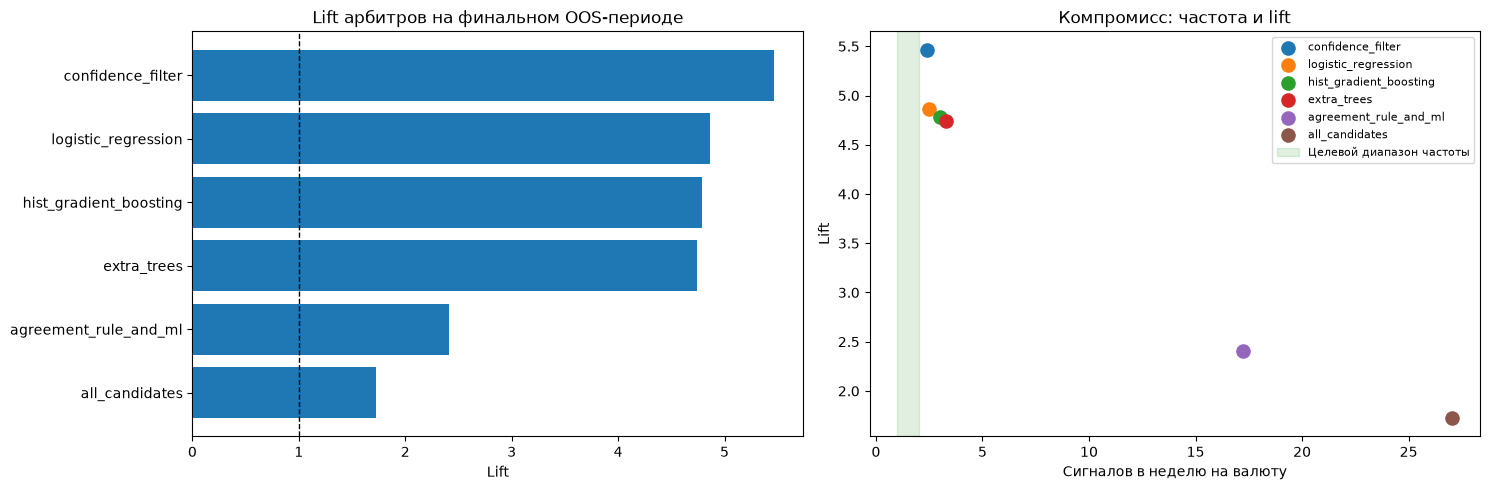

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_data = arbiter_comparison.sort_values('test_lift')
axes[0].barh(plot_data['arbiter'], plot_data['test_lift'])
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Lift арбитров на финальном OOS-периоде')
axes[0].set_xlabel('Lift')

for _, row in arbiter_comparison.iterrows():
    axes[1].scatter(
        row['test_signals_per_week_per_currency'],
        row['test_lift'],
        s=90,
        label=row['arbiter'],
    )
axes[1].axvspan(
    META_MIN_SIGNALS_PER_WEEK,
    META_MAX_SIGNALS_PER_WEEK,
    color='green',
    alpha=0.12,
    label='Целевой диапазон частоты',
)
axes[1].set_title('Компромисс: частота и lift')
axes[1].set_xlabel('Сигналов в неделю на валюту')
axes[1].set_ylabel('Lift')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 7.1. Lift каждого арбитра по валютам

Эта таблица не смешивает валюты в один показатель. Строка — вариант арбитра, столбец — валюта, значение — финальный OOS lift с 2025 года. `mean_lift` и `min_lift` помогают увидеть среднее качество и устойчивость худшей валюты.

In [13]:
currency_comparison_parts = []

for arbiter_name, events in arbiter_events.items():
    summary, _ = backtest_signal_stream(
        events,
        evaluation_universe=evaluation_universe,
    )
    currency_part = summary.loc[
        summary['scope'].eq('currency'),
        ['currency', 'lift', 'precision', 'signals_per_week'],
    ].copy()
    currency_part.insert(0, 'arbiter', arbiter_name)
    currency_comparison_parts.append(currency_part)

arbiter_currency_comparison = pd.concat(
    currency_comparison_parts,
    ignore_index=True,
)

currency_order = list(PRODUCTION_CURRENCIES)
arbiter_order = arbiter_comparison['arbiter'].tolist()

arbiter_lift_by_currency = (
    arbiter_currency_comparison
    .pivot(index='arbiter', columns='currency', values='lift')
    .reindex(index=arbiter_order, columns=currency_order)
)
arbiter_lift_by_currency['mean_lift'] = (
    arbiter_lift_by_currency[currency_order].mean(axis=1)
)
arbiter_lift_by_currency['min_lift'] = (
    arbiter_lift_by_currency[currency_order].min(axis=1)
)

ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
arbiter_currency_comparison.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_metrics_by_currency.csv',
    index=False,
)
arbiter_lift_by_currency.reset_index().to_json(
    ARBITER_OUTPUT_DIR / 'arbiter_lift_by_currency.json',
    orient='records',
    force_ascii=False,
    indent=2,
)

display(arbiter_lift_by_currency.round(2))


currency,AMD,KZT,KGS,TJS,UZS,mean_lift,min_lift
arbiter,,,,,,,
confidence_filter,5.45,5.74,5.15,5.79,5.25,5.48,5.15
logistic_regression,5.01,4.92,4.82,4.97,4.59,4.86,4.59
hist_gradient_boosting,5.59,5.70,4.89,4.48,3.96,4.92,3.96
extra_trees,5.30,5.37,4.73,4.82,3.85,4.81,3.85
agreement_rule_and_ml,2.26,2.43,2.18,2.82,2.44,2.42,2.18
all_candidates,1.58,1.84,1.62,1.82,1.80,1.73,1.58


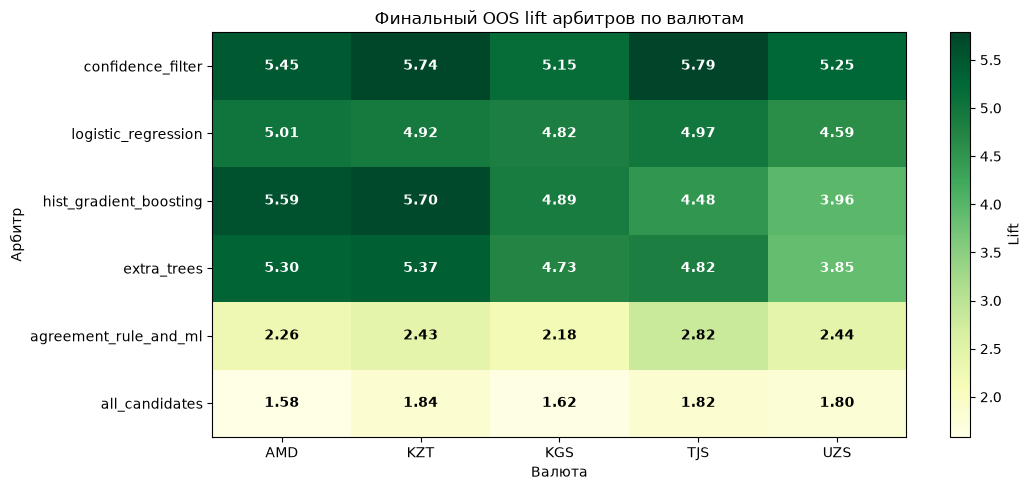

In [14]:
import matplotlib.pyplot as plt

lift_matrix = arbiter_lift_by_currency[currency_order]
figure_height = max(5, 0.65 * len(lift_matrix))
fig, ax = plt.subplots(figsize=(11, figure_height))

image = ax.imshow(
    lift_matrix.to_numpy(dtype=float),
    cmap='YlGn',
    aspect='auto',
)
ax.set_xticks(range(len(currency_order)), labels=currency_order)
ax.set_yticks(
    range(len(lift_matrix.index)),
    labels=lift_matrix.index,
)
ax.set_xlabel('Валюта')
ax.set_ylabel('Арбитр')
ax.set_title('Финальный OOS lift арбитров по валютам')

matrix_values = lift_matrix.to_numpy(dtype=float)
midpoint = (
    np.nanmin(matrix_values)
    + np.nanmax(matrix_values)
) / 2
for row_index in range(matrix_values.shape[0]):
    for column_index in range(matrix_values.shape[1]):
        value = matrix_values[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f'{value:.2f}',
            ha='center',
            va='center',
            color='white' if value > midpoint else 'black',
            fontweight='bold',
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('Lift')
plt.tight_layout()
plt.show()


### 7.2. BPS быстрых и медленных сигналов

Быстрые сигналы — горизонты 1 и 3 дня, медленные — 10 и 20 дней. Горизонт 5 дней не входит в пару «быстрые/медленные», но учитывается в общем среднем BPS арбитра. Для каждого арбитра считаются количество сигналов, средний и медианный `benefit_bps`, а также доля сигналов с положительным эффектом.

Абсолютный BPS медленных сигналов естественно может быть выше из-за более длинного горизонта, поэтому этот график нужно рассматривать вместе с lift и частотой.

In [15]:
if 'arbiter_events' not in globals():
    raise RuntimeError(
        'Сначала запустите раздел 7 «Сравнение разных арбитров»'
    )

FAST_HORIZONS = (1, 3)
SLOW_HORIZONS = (10, 20)

all_arbiter_signal_parts = []
fast_slow_signal_parts = []
for arbiter_name, events in arbiter_events.items():
    _, backtest_rows = backtest_signal_stream(
        events,
        evaluation_universe=evaluation_universe,
    )
    signals = backtest_rows.loc[backtest_rows['signal']].copy()
    signals.insert(0, 'arbiter', arbiter_name)
    all_arbiter_signal_parts.append(signals.copy())
    signals['speed'] = np.select(
        [
            signals['horizon'].isin(FAST_HORIZONS),
            signals['horizon'].isin(SLOW_HORIZONS),
        ],
        ['fast_1_3d', 'slow_10_20d'],
        default='middle_5d',
    )
    signals = signals.loc[
        signals['speed'].isin(['fast_1_3d', 'slow_10_20d'])
    ].copy()
    fast_slow_signal_parts.append(signals)

arbiter_all_signals = pd.concat(
    all_arbiter_signal_parts,
    ignore_index=True,
)
arbiter_fast_slow_signals = pd.concat(
    fast_slow_signal_parts,
    ignore_index=True,
)
arbiter_fast_slow_signals['benefit_bps'] = pd.to_numeric(
    arbiter_fast_slow_signals['benefit_bps'],
    errors='coerce',
)
arbiter_all_signals['benefit_bps'] = pd.to_numeric(
    arbiter_all_signals['benefit_bps'],
    errors='coerce',
)

arbiter_overall_bps = (
    arbiter_all_signals
    .dropna(subset=['benefit_bps'])
    .groupby('arbiter', as_index=False)
    .agg(
        overall_signal_count=('benefit_bps', 'size'),
        overall_mean_bps=('benefit_bps', 'mean'),
        overall_median_bps=('benefit_bps', 'median'),
    )
)
arbiter_overall_bps_by_currency = (
    arbiter_all_signals
    .dropna(subset=['benefit_bps'])
    .groupby(['arbiter', 'currency'], as_index=False)
    .agg(overall_mean_bps=('benefit_bps', 'mean'))
)

arbiter_fast_slow_bps = (
    arbiter_fast_slow_signals
    .dropna(subset=['benefit_bps'])
    .groupby(['arbiter', 'speed'], as_index=False)
    .agg(
        signal_count=('benefit_bps', 'size'),
        mean_benefit_bps=('benefit_bps', 'mean'),
        median_benefit_bps=('benefit_bps', 'median'),
        positive_benefit_rate=(
            'benefit_bps',
            lambda values: float((values > 0).mean()),
        ),
    )
)

arbiter_fast_slow_bps_by_currency = (
    arbiter_fast_slow_signals
    .dropna(subset=['benefit_bps'])
    .groupby(['arbiter', 'currency', 'speed'], as_index=False)
    .agg(
        signal_count=('benefit_bps', 'size'),
        mean_benefit_bps=('benefit_bps', 'mean'),
        median_benefit_bps=('benefit_bps', 'median'),
        positive_benefit_rate=(
            'benefit_bps',
            lambda values: float((values > 0).mean()),
        ),
    )
)

speed_order = ['fast_1_3d', 'slow_10_20d']
arbiter_order = arbiter_comparison['arbiter'].tolist()

fast_slow_bps_table = (
    arbiter_fast_slow_bps
    .pivot(index='arbiter', columns='speed', values='mean_benefit_bps')
    .reindex(index=arbiter_order, columns=speed_order)
    .rename(columns={
        'fast_1_3d': 'fast_mean_bps',
        'slow_10_20d': 'slow_mean_bps',
    })
)
fast_slow_bps_table = fast_slow_bps_table.join(
    arbiter_overall_bps.set_index('arbiter')['overall_mean_bps']
)
fast_slow_bps_table['slow_minus_fast_bps'] = (
    fast_slow_bps_table['slow_mean_bps']
    - fast_slow_bps_table['fast_mean_bps']
)

ARBITER_OUTPUT_DIR = PROJECT_ROOT / 'research' / 'aleksandr' / 'outputs'
ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
arbiter_fast_slow_bps.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_fast_slow_bps.csv',
    index=False,
)
arbiter_fast_slow_bps_by_currency.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_fast_slow_bps_by_currency.csv',
    index=False,
)
arbiter_overall_bps.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_overall_mean_bps.csv',
    index=False,
)

display(fast_slow_bps_table.round(2))
display(
    arbiter_fast_slow_bps[
        [
            'arbiter',
            'speed',
            'signal_count',
            'mean_benefit_bps',
            'median_benefit_bps',
            'positive_benefit_rate',
        ]
    ].round(3)
)


,fast_mean_bps,slow_mean_bps,overall_mean_bps,slow_minus_fast_bps
arbiter,,,,
confidence_filter,20.83,NaN,20.83,NaN
logistic_regression,24.45,81.58,36.41,57.13
hist_gradient_boosting,22.37,80.71,33.29,58.34
extra_trees,20.51,82.41,40.36,61.90
agreement_rule_and_ml,23.32,65.25,42.41,41.94
all_candidates,16.29,34.05,26.05,17.76


,arbiter,speed,signal_count,mean_benefit_bps,median_benefit_bps,positive_benefit_rate
0,agreement_rule_and_ml,fast_1_3d,3110,23.318,18.266,0.709
1,agreement_rule_and_ml,slow_10_20d,2789,65.253,55.303,0.736
2,all_candidates,fast_1_3d,4436,16.286,13.231,0.654
3,all_candidates,slow_10_20d,4946,34.046,35.745,0.642
4,confidence_filter,fast_1_3d,1025,20.834,16.754,0.789
5,extra_trees,fast_1_3d,955,20.507,16.358,0.786
6,extra_trees,slow_10_20d,451,82.411,77.979,0.794
7,hist_gradient_boosting,fast_1_3d,1038,22.366,17.321,0.786
8,hist_gradient_boosting,slow_10_20d,233,80.707,79.765,0.734
9,logistic_regression,fast_1_3d,846,24.450,17.916,0.798


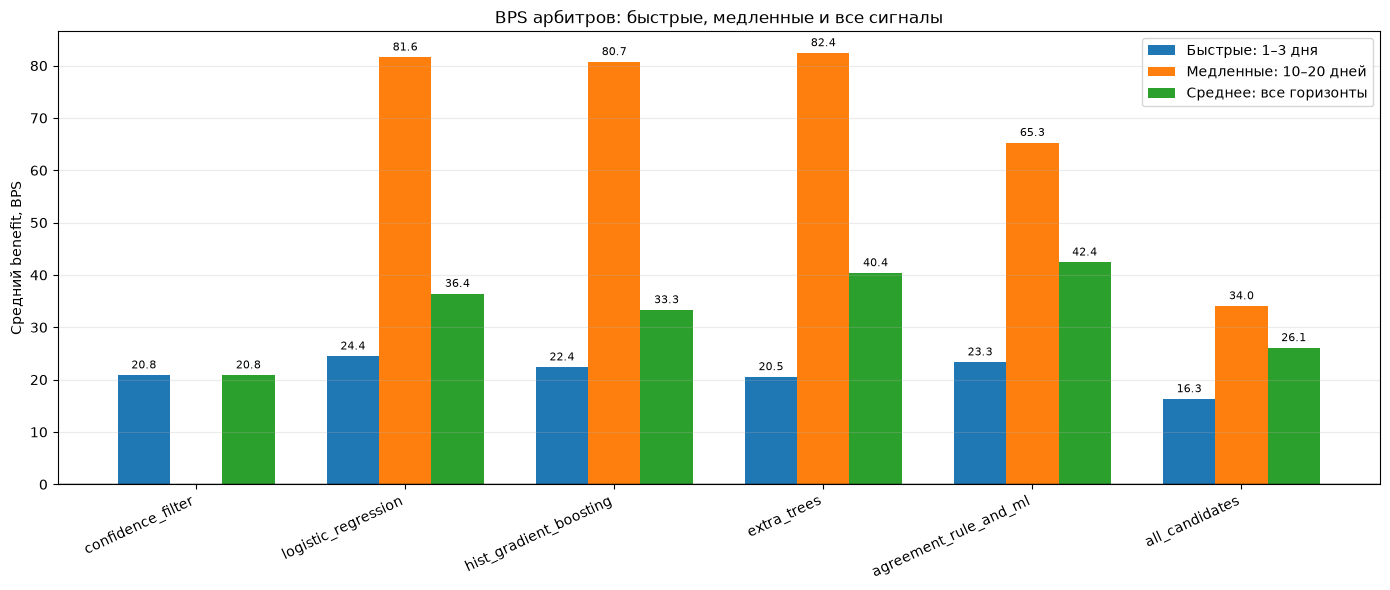

In [16]:
import matplotlib.pyplot as plt

bar_data = fast_slow_bps_table.loc[arbiter_order]
positions = np.arange(len(bar_data))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
fast_bars = ax.bar(
    positions - width,
    bar_data['fast_mean_bps'],
    width,
    label='Быстрые: 1–3 дня',
)
slow_bars = ax.bar(
    positions,
    bar_data['slow_mean_bps'],
    width,
    label='Медленные: 10–20 дней',
)
overall_bars = ax.bar(
    positions + width,
    bar_data['overall_mean_bps'],
    width,
    label='Среднее: все горизонты',
    color='tab:green',
)

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(
    positions,
    labels=bar_data.index,
    rotation=25,
    ha='right',
)
ax.set_ylabel('Средний benefit, BPS')
ax.set_title('BPS арбитров: быстрые, медленные и все сигналы')
ax.legend()
ax.grid(axis='y', alpha=0.25)

for bars in (fast_bars, slow_bars, overall_bars):
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)

plt.tight_layout()
ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(
    ARBITER_PLOT_DIR / 'fast_vs_slow_bps_by_arbiter.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()


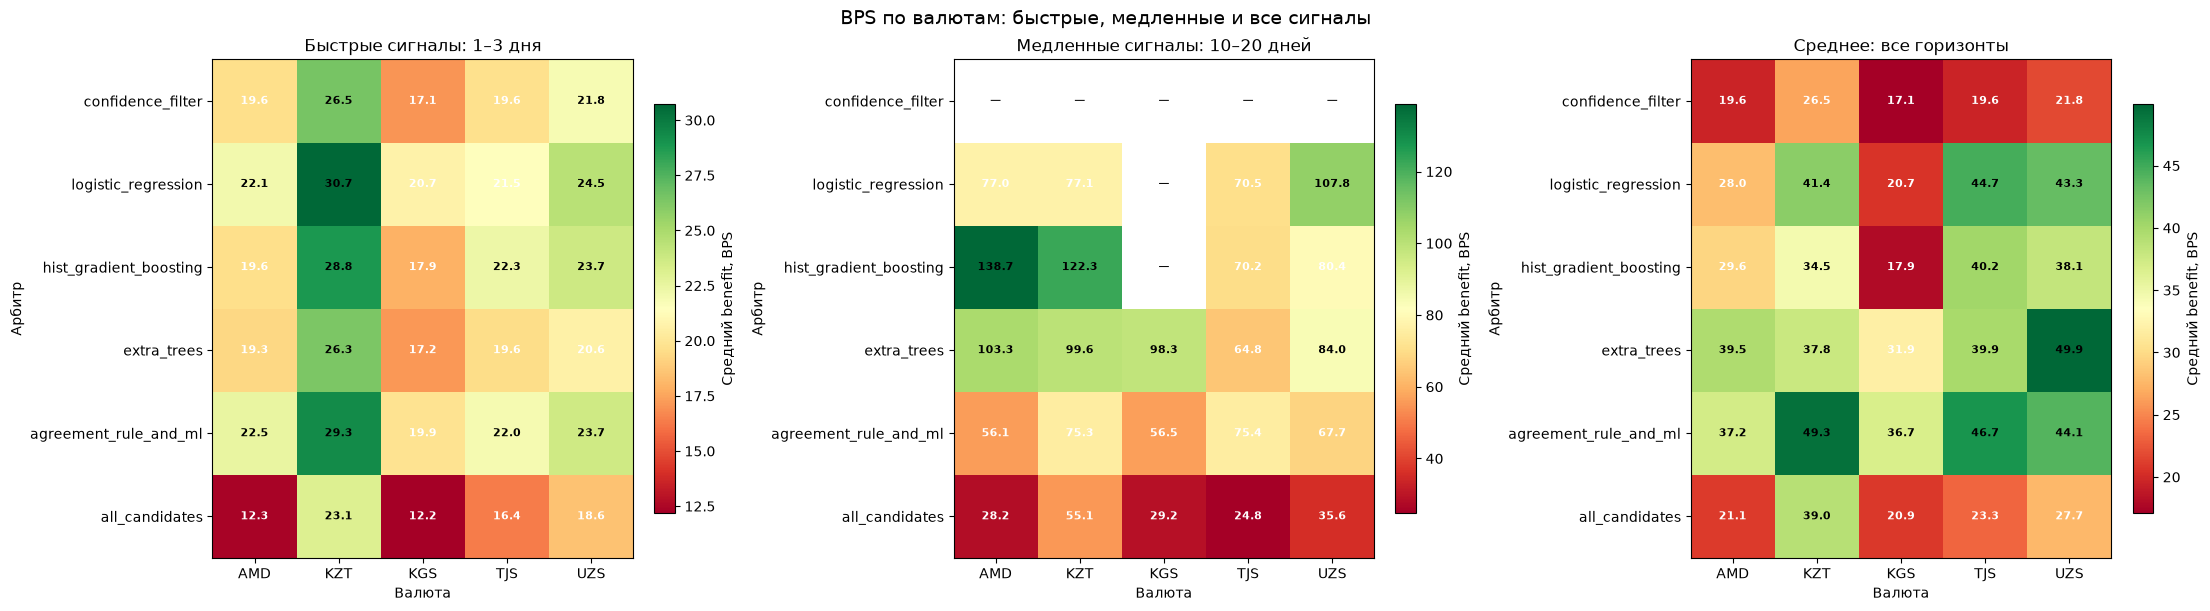

In [17]:
currency_order = list(PRODUCTION_CURRENCIES)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

heatmap_panels = (
    ('fast_1_3d', 'Быстрые сигналы: 1–3 дня'),
    ('slow_10_20d', 'Медленные сигналы: 10–20 дней'),
    ('overall', 'Среднее: все горизонты'),
)

for ax, panel in zip(axes, heatmap_panels, strict=True):
    speed, panel_title = panel
    if speed == 'overall':
        matrix = (
            arbiter_overall_bps_by_currency
            .pivot(index='arbiter', columns='currency', values='overall_mean_bps')
            .reindex(index=arbiter_order, columns=currency_order)
        )
    else:
        matrix = (
            arbiter_fast_slow_bps_by_currency
            .loc[lambda frame: frame['speed'].eq(speed)]
            .pivot(index='arbiter', columns='currency', values='mean_benefit_bps')
            .reindex(index=arbiter_order, columns=currency_order)
        )
    values = matrix.to_numpy(dtype=float)
    image = ax.imshow(values, cmap='RdYlGn', aspect='auto')

    ax.set_xticks(range(len(currency_order)), labels=currency_order)
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    ax.set_title(panel_title)
    ax.set_xlabel('Валюта')
    ax.set_ylabel('Арбитр')

    finite_values = values[np.isfinite(values)]
    midpoint = (
        float(np.nanmin(finite_values) + np.nanmax(finite_values)) / 2
        if len(finite_values)
        else 0.0
    )
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            label = '—' if not np.isfinite(value) else f'{value:.1f}'
            ax.text(
                column_index,
                row_index,
                label,
                ha='center',
                va='center',
                color=(
                    'white'
                    if np.isfinite(value) and value < midpoint
                    else 'black'
                ),
                fontweight='bold',
                fontsize=8,
            )

    colorbar = fig.colorbar(image, ax=ax, shrink=0.82)
    colorbar.set_label('Средний benefit, BPS')

fig.suptitle('BPS по валютам: быстрые, медленные и все сигналы', fontsize=14)
ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(
    ARBITER_PLOT_DIR / 'fast_vs_slow_bps_by_currency.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()


### 7.3. Вклад быстрых и медленных сигналов и теоретический максимум BPS

Вклад в итоговый эффект считается как сумма `benefit_bps` всех сигналов группы. Отдельно показаны быстрые (1–3 дня), средние (5 дней) и медленные (10–20 дней) сигналы.

Теоретический оракул имеет тот же бюджет сигналов, что и арбитр, и выбирает лучшие по будущему `benefit_bps` даты внутри той же валюты, target family и горизонта. Дополнительно строится единый оракул с одинаковым для всех бюджетом 1,5 сигнала в неделю на валюту и квотами 40% / 20% / 40% для быстрых, 5-дневных и медленных сигналов. Эти оценки недостижимы в production из-за утечки будущего и нужны только как верхние границы. Сумма BPS здесь — атрибуция возможностей, а не бухгалтерски аддитивный P&L.

In [18]:
if 'arbiter_all_signals' not in globals():
    raise RuntimeError('Сначала запустите расчётную ячейку раздела 7.2')

ATTRIBUTION_SPEED_ORDER = ['fast_1_3d', 'middle_5d', 'slow_10_20d']
ATTRIBUTION_SPEED_LABELS = {
    'fast_1_3d': 'Быстрые: 1–3 дня',
    'middle_5d': 'Средние: 5 дней',
    'slow_10_20d': 'Медленные: 10–20 дней',
}

def add_speed_group(frame):
    result = frame.copy()
    result['speed'] = np.select(
        [
            result['horizon'].isin(FAST_HORIZONS),
            result['horizon'].isin(SLOW_HORIZONS),
        ],
        ['fast_1_3d', 'slow_10_20d'],
        default='middle_5d',
    )
    return result

actual_signals = add_speed_group(arbiter_all_signals)
actual_signals['benefit_bps'] = pd.to_numeric(
    actual_signals['benefit_bps'], errors='coerce'
)
actual_signals = actual_signals.dropna(subset=['benefit_bps']).copy()

actual_attribution = (
    actual_signals
    .groupby(['arbiter', 'speed'], as_index=False)
    .agg(
        signal_count=('benefit_bps', 'size'),
        actual_total_bps=('benefit_bps', 'sum'),
        actual_mean_bps=('benefit_bps', 'mean'),
    )
)
actual_totals = (
    actual_attribution
    .groupby('arbiter', as_index=False)
    .agg(
        total_signal_count=('signal_count', 'sum'),
        total_effect_bps=('actual_total_bps', 'sum'),
    )
)
actual_attribution = actual_attribution.merge(
    actual_totals, on='arbiter', how='left', validate='many_to_one'
)
actual_attribution['signal_share_pct'] = (
    100 * actual_attribution['signal_count']
    / actual_attribution['total_signal_count']
)
actual_attribution['effect_share_pct'] = np.where(
    actual_attribution['total_effect_bps'].ne(0),
    100 * actual_attribution['actual_total_bps']
    / actual_attribution['total_effect_bps'],
    np.nan,
)

# Пул оракула ограничен теми датами, где был хотя бы один базовый candidate.
oracle_candidates = build_meta_candidates(final_raw_signal_stream)
oracle_pool = oracle_candidates[meta_keys].merge(
    evaluation_universe[meta_keys + ['benefit_bps']],
    on=meta_keys,
    how='inner',
    validate='one_to_one',
)
oracle_pool['benefit_bps'] = pd.to_numeric(
    oracle_pool['benefit_bps'], errors='coerce'
)
oracle_pool = add_speed_group(
    oracle_pool.dropna(subset=['benefit_bps'])
)

ORACLE_GROUP_COLUMNS = [
    'currency', 'scenario', 'target_family', 'target', 'horizon'
]
actual_group_counts = (
    actual_signals
    .groupby(['arbiter', *ORACLE_GROUP_COLUMNS, 'speed'], as_index=False)
    .size()
    .rename(columns={'size': 'signal_count'})
)

oracle_rows = []
for row in actual_group_counts.itertuples(index=False):
    candidates = oracle_pool
    for column in ORACLE_GROUP_COLUMNS:
        candidates = candidates.loc[
            candidates[column].eq(getattr(row, column))
        ]
    selected = candidates.nlargest(int(row.signal_count), 'benefit_bps')
    if len(selected) != int(row.signal_count):
        raise RuntimeError(
            'Оракулу не хватило candidates для того же бюджета сигналов'
        )
    oracle_rows.append({
        'arbiter': row.arbiter,
        'speed': row.speed,
        'oracle_signal_count': len(selected),
        'oracle_total_bps': selected['benefit_bps'].sum(),
    })

oracle_attribution = (
    pd.DataFrame(oracle_rows)
    .groupby(['arbiter', 'speed'], as_index=False)
    .agg(
        oracle_signal_count=('oracle_signal_count', 'sum'),
        oracle_total_bps=('oracle_total_bps', 'sum'),
    )
)
oracle_attribution['oracle_mean_bps'] = (
    oracle_attribution['oracle_total_bps']
    / oracle_attribution['oracle_signal_count']
)

arbiter_bps_attribution = actual_attribution.merge(
    oracle_attribution,
    on=['arbiter', 'speed'],
    how='left',
    validate='one_to_one',
)
arbiter_bps_attribution['oracle_capture_pct'] = np.where(
    arbiter_bps_attribution['oracle_total_bps'].gt(0),
    100 * arbiter_bps_attribution['actual_total_bps']
    / arbiter_bps_attribution['oracle_total_bps'],
    np.nan,
)
arbiter_bps_attribution['speed'] = pd.Categorical(
    arbiter_bps_attribution['speed'],
    categories=ATTRIBUTION_SPEED_ORDER,
    ordered=True,
)
arbiter_bps_attribution = arbiter_bps_attribution.sort_values(
    ['arbiter', 'speed']
)

arbiter_oracle_summary = (
    arbiter_bps_attribution
    .groupby('arbiter', as_index=False, observed=True)
    .agg(
        signal_count=('signal_count', 'sum'),
        actual_total_bps=('actual_total_bps', 'sum'),
        oracle_total_bps=('oracle_total_bps', 'sum'),
    )
)
arbiter_oracle_summary['actual_mean_bps'] = (
    arbiter_oracle_summary['actual_total_bps']
    / arbiter_oracle_summary['signal_count']
)
arbiter_oracle_summary['oracle_mean_bps'] = (
    arbiter_oracle_summary['oracle_total_bps']
    / arbiter_oracle_summary['signal_count']
)
arbiter_oracle_summary['oracle_gap_bps'] = (
    arbiter_oracle_summary['oracle_total_bps']
    - arbiter_oracle_summary['actual_total_bps']
)
arbiter_oracle_summary['oracle_capture_pct'] = np.where(
    arbiter_oracle_summary['oracle_total_bps'].gt(0),
    100 * arbiter_oracle_summary['actual_total_bps']
    / arbiter_oracle_summary['oracle_total_bps'],
    np.nan,
)
arbiter_oracle_summary = (
    arbiter_oracle_summary
    .set_index('arbiter')
    .reindex(arbiter_order)
    .reset_index()
)

# Одинаковый оракул для всех арбитров: 1.5 сигнала в неделю на валюту.
# Квоты 40/20/40 соответствуют одинаковой доле на каждый из пяти горизонтов.
COMMON_ORACLE_SIGNALS_PER_WEEK_PER_CURRENCY = 1.5
COMMON_ORACLE_SPEED_WEIGHTS = {
    'fast_1_3d': 0.40,
    'middle_5d': 0.20,
    'slow_10_20d': 0.40,
}

def allocate_integer_budget(total_budget, weights):
    raw = {name: total_budget * weight for name, weight in weights.items()}
    quotas = {name: int(np.floor(value)) for name, value in raw.items()}
    remainder = total_budget - sum(quotas.values())
    priority = sorted(
        raw, key=lambda name: raw[name] - quotas[name], reverse=True
    )
    for name in priority[:remainder]:
        quotas[name] += 1
    return quotas

common_oracle_rows = []
for currency in PRODUCTION_CURRENCIES:
    currency_dates = pd.to_datetime(
        evaluation_universe.loc[
            evaluation_universe['currency'].eq(currency), 'available_at'
        ]
    )
    span_days = max(
        (currency_dates.max() - currency_dates.min()).days + 1, 1
    )
    total_budget = int(round(
        COMMON_ORACLE_SIGNALS_PER_WEEK_PER_CURRENCY * span_days / 7
    ))
    quotas = allocate_integer_budget(total_budget, COMMON_ORACLE_SPEED_WEIGHTS)

    for speed, requested_count in quotas.items():
        candidates = oracle_pool.loc[
            oracle_pool['currency'].eq(currency)
            & oracle_pool['speed'].eq(speed)
        ]
        selected = candidates.nlargest(requested_count, 'benefit_bps')
        if len(selected) != requested_count:
            raise RuntimeError(
                f'Для {currency}/{speed} не хватает candidates: '
                f'нужно {requested_count}, есть {len(candidates)}'
            )
        common_oracle_rows.append({
            'currency': currency,
            'speed': speed,
            'signal_count': len(selected),
            'total_bps': selected['benefit_bps'].sum(),
            'mean_bps': selected['benefit_bps'].mean(),
        })

common_oracle_by_currency_speed = pd.DataFrame(common_oracle_rows)
common_oracle_signal_count = int(
    common_oracle_by_currency_speed['signal_count'].sum()
)
common_oracle_total_bps = float(
    common_oracle_by_currency_speed['total_bps'].sum()
)
common_oracle_mean_bps = (
    common_oracle_total_bps / common_oracle_signal_count
)
common_oracle_summary = pd.DataFrame([{
    'signals_per_week_per_currency': COMMON_ORACLE_SIGNALS_PER_WEEK_PER_CURRENCY,
    'signal_count': common_oracle_signal_count,
    'total_bps': common_oracle_total_bps,
    'mean_bps': common_oracle_mean_bps,
}])
arbiter_oracle_summary['common_oracle_mean_bps'] = common_oracle_mean_bps
arbiter_oracle_summary['actual_vs_common_oracle_pct'] = np.where(
    common_oracle_mean_bps > 0,
    100 * arbiter_oracle_summary['actual_mean_bps']
    / common_oracle_mean_bps,
    np.nan,
)

ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
arbiter_bps_attribution.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_bps_attribution.csv', index=False
)
arbiter_oracle_summary.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_bps_oracle_summary.csv', index=False
)
common_oracle_by_currency_speed.to_csv(
    ARBITER_OUTPUT_DIR / 'common_oracle_bps_by_currency_speed.csv',
    index=False,
)
common_oracle_summary.to_csv(
    ARBITER_OUTPUT_DIR / 'common_oracle_bps_summary.csv', index=False
)

display(arbiter_bps_attribution[[
    'arbiter', 'speed', 'signal_count', 'actual_total_bps',
    'actual_mean_bps', 'signal_share_pct', 'effect_share_pct',
    'oracle_mean_bps', 'oracle_capture_pct',
]].round(2))
display(arbiter_oracle_summary.round(2))
display(common_oracle_by_currency_speed.round(2))
display(common_oracle_summary.round(2))


,arbiter,speed,signal_count,actual_total_bps,actual_mean_bps,signal_share_pct,effect_share_pct,oracle_mean_bps,oracle_capture_pct
0,agreement_rule_and_ml,fast_1_3d,3110,72519.17,23.32,41.96,23.07,39.87,58.49
1,agreement_rule_and_ml,middle_5d,1512,59775.04,39.53,20.40,19.02,66.34,59.59
2,agreement_rule_and_ml,slow_10_20d,2789,181991.29,65.25,37.63,57.91,119.05,54.81
3,all_candidates,fast_1_3d,4436,72243.80,16.29,38.14,23.84,16.29,100.00
4,all_candidates,middle_5d,2248,62377.66,27.75,19.33,20.59,27.75,100.00
5,all_candidates,slow_10_20d,4946,168392.20,34.05,42.53,55.57,34.05,100.00
6,confidence_filter,fast_1_3d,1025,21354.56,20.83,100.00,100.00,20.83,100.00
7,extra_trees,fast_1_3d,955,19584.05,20.51,67.92,34.51,25.46,80.54
8,extra_trees,slow_10_20d,451,37167.46,82.41,32.08,65.49,184.38,44.70
9,hist_gradient_boosting,fast_1_3d,1038,23215.77,22.37,79.91,53.68,34.86,64.17


,arbiter,signal_count,actual_total_bps,oracle_total_bps,actual_mean_bps,oracle_mean_bps,oracle_gap_bps,oracle_capture_pct,common_oracle_mean_bps,actual_vs_common_oracle_pct
0,confidence_filter,1025,21354.56,21354.56,20.83,20.83,-0.00,100.00,222.75,9.35
1,logistic_regression,1062,38665.06,88023.72,36.41,82.88,49358.65,43.93,222.75,16.34
2,hist_gradient_boosting,1299,43249.94,91204.15,33.29,70.21,47954.21,47.42,222.75,14.95
3,extra_trees,1406,56751.51,107470.69,40.36,76.44,50719.18,52.81,222.75,18.12
4,agreement_rule_and_ml,7411,314285.51,556313.93,42.41,75.07,242028.42,56.49,222.75,19.04
5,all_candidates,11630,303013.67,303013.67,26.05,26.05,0.00,100.00,222.75,11.70


,currency,speed,signal_count,total_bps,mean_bps
0,AMD,fast_1_3d,52,6837.87,131.50
1,AMD,middle_5d,26,5245.89,201.76
2,AMD,slow_10_20d,51,15019.90,294.51
3,KZT,fast_1_3d,52,7898.11,151.89
4,KZT,middle_5d,26,5471.03,210.42
5,KZT,slow_10_20d,51,17136.62,336.01
6,KGS,fast_1_3d,52,6901.60,132.72
7,KGS,middle_5d,26,5190.63,199.64
8,KGS,slow_10_20d,51,15306.12,300.12
9,TJS,fast_1_3d,52,7597.30,146.10


,signals_per_week_per_currency,signal_count,total_bps,mean_bps
0,1.5,645,143671.12,222.75


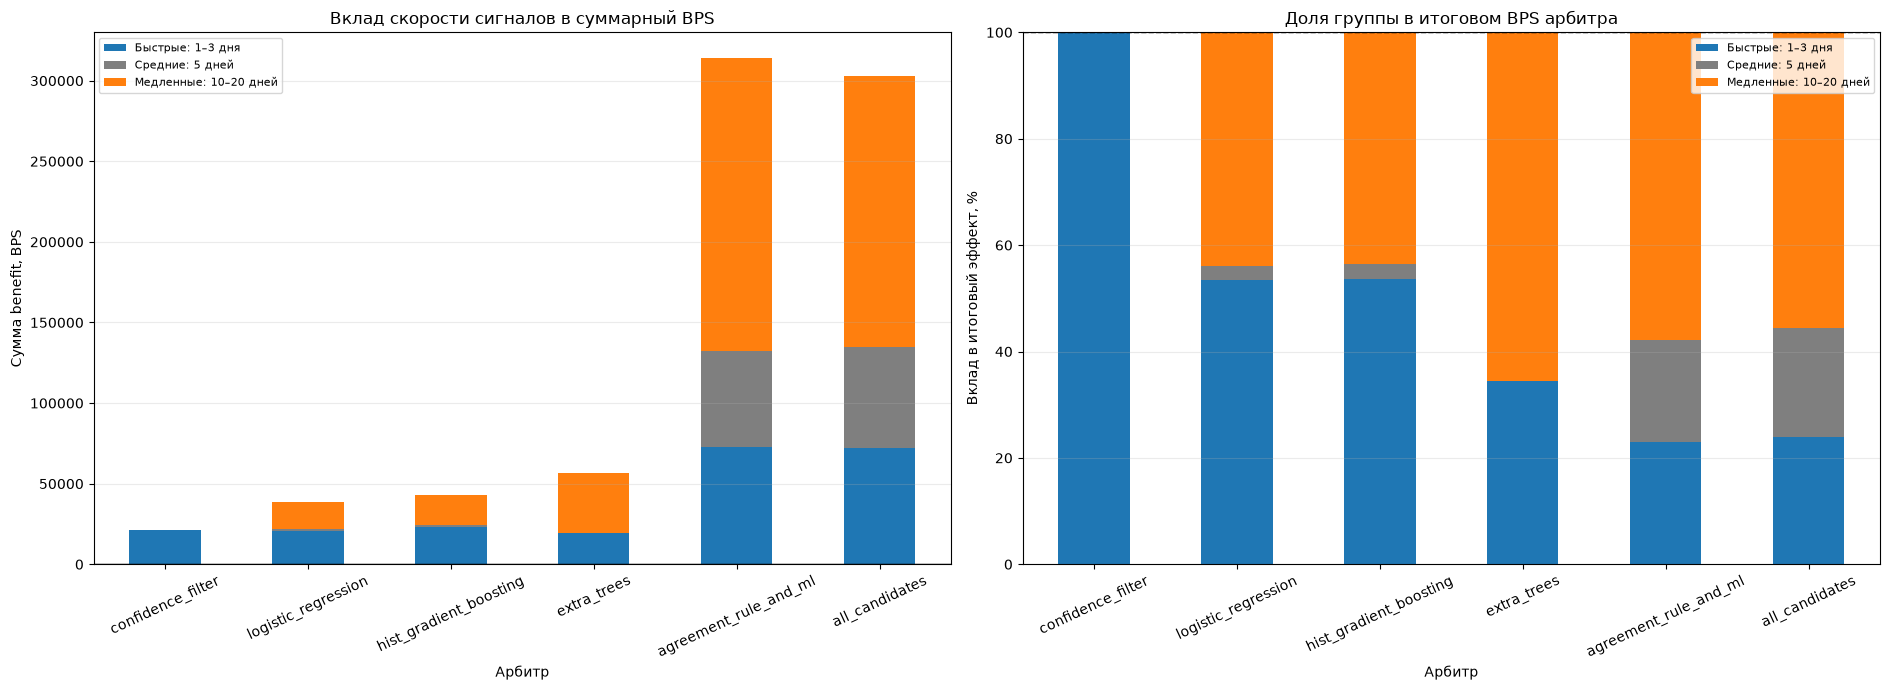

In [19]:
contribution_matrix = (
    arbiter_bps_attribution
    .pivot(index='arbiter', columns='speed', values='actual_total_bps')
    .reindex(index=arbiter_order, columns=ATTRIBUTION_SPEED_ORDER)
    .fillna(0.0)
)
share_matrix = (
    arbiter_bps_attribution
    .pivot(index='arbiter', columns='speed', values='effect_share_pct')
    .reindex(index=arbiter_order, columns=ATTRIBUTION_SPEED_ORDER)
    .fillna(0.0)
)
plot_labels = [ATTRIBUTION_SPEED_LABELS[column] for column in ATTRIBUTION_SPEED_ORDER]
plot_colors = ['tab:blue', 'tab:gray', 'tab:orange']

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
contribution_matrix.rename(columns=ATTRIBUTION_SPEED_LABELS).plot(
    kind='bar', stacked=True, ax=axes[0], color=plot_colors
)
axes[0].set_title('Вклад скорости сигналов в суммарный BPS')
axes[0].set_ylabel('Сумма benefit, BPS')
axes[0].set_xlabel('Арбитр')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].grid(axis='y', alpha=0.25)

share_matrix.rename(columns=ATTRIBUTION_SPEED_LABELS).plot(
    kind='bar', stacked=True, ax=axes[1], color=plot_colors
)
axes[1].set_title('Доля группы в итоговом BPS арбитра')
axes[1].set_ylabel('Вклад в итоговый эффект, %')
axes[1].set_xlabel('Арбитр')
axes[1].axhline(100, color='black', linewidth=1, linestyle='--')
axes[1].grid(axis='y', alpha=0.25)

for ax in axes:
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(
    ARBITER_PLOT_DIR / 'bps_contribution_by_signal_speed.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


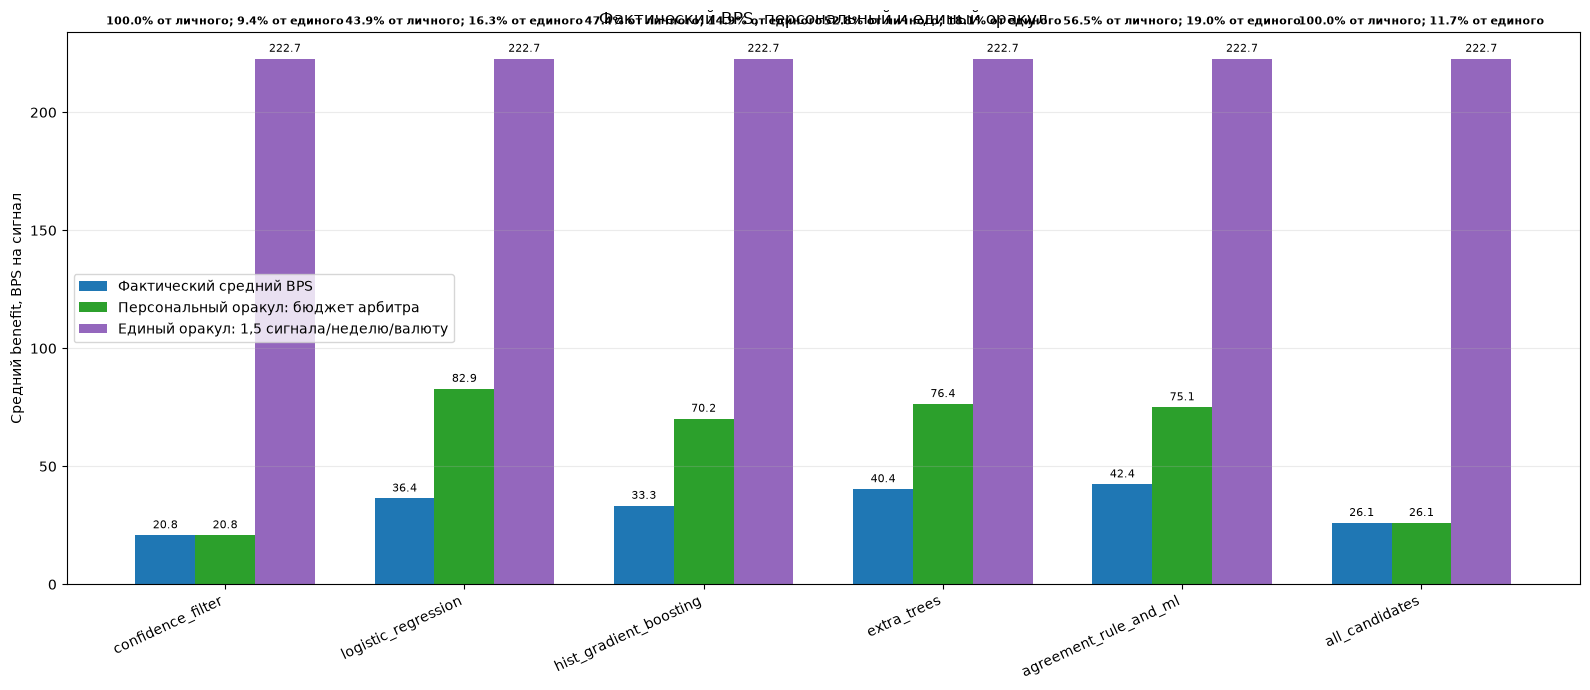

In [20]:
oracle_plot = arbiter_oracle_summary.set_index('arbiter').loc[arbiter_order]
positions = np.arange(len(oracle_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
actual_bars = ax.bar(
    positions - width, oracle_plot['actual_mean_bps'], width,
    label='Фактический средний BPS',
)
oracle_bars = ax.bar(
    positions, oracle_plot['oracle_mean_bps'], width,
    label='Персональный оракул: бюджет арбитра', color='tab:green',
)
common_oracle_bars = ax.bar(
    positions + width, oracle_plot['common_oracle_mean_bps'], width,
    label='Единый оракул: 1,5 сигнала/неделю/валюту',
    color='tab:purple',
)
ax.set_xticks(positions, labels=oracle_plot.index, rotation=25, ha='right')
ax.set_ylabel('Средний benefit, BPS на сигнал')
ax.set_title('Фактический BPS, персональный и единый оракул')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.bar_label(actual_bars, fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(oracle_bars, fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(common_oracle_bars, fmt='%.1f', padding=3, fontsize=8)

for index, row in oracle_plot.reset_index().iterrows():
    height = max(
        row['actual_mean_bps'],
        row['oracle_mean_bps'],
        row['common_oracle_mean_bps'],
    )
    ax.text(
        index, height * 1.06,
        (
            f'{row["oracle_capture_pct"]:.1f}% от личного; '
            f'{row["actual_vs_common_oracle_pct"]:.1f}% от единого'
        ),
        ha='center', va='bottom', fontsize=8, fontweight='bold',
    )

plt.tight_layout()
fig.savefig(
    ARBITER_PLOT_DIR / 'actual_vs_oracle_mean_bps.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


### 7.4. Cooldown между сообщениями

Cooldown применяется **после арбитра** и не меняе обученные модели. В каждый день по валюте берётся кандидат с наибольшей confidence; после отправки новые сообщения по этой валюте блокируются на 3, 5 или 7 дней. Вариант 0 дней — текущий baseline без ограничения.

В реальном сервисе состояние cooldown нужно хранить по `recipient_id × currency`. В исследовательских данных `recipient_id` нет, поэтому мы моделируем один поток сообщений на валюту. Выбор cooldown по финальному OOS-периоду здесь является исследовательским: перед production значение нужно зафиксировать и проверить на новом периоде.

In [21]:
if 'arbiter_events' not in globals():
    raise RuntimeError('Сначала запустите раздел 7 «Сравнение разных арбитров»')

COOLDOWN_DAYS_TO_TEST = (0, 3, 5, 7)

def apply_currency_cooldown(events, cooldown_days):
    """Online-style cooldown: решение на дату не использует будущие сигналы."""
    if cooldown_days < 0:
        raise ValueError('cooldown_days не может быть отрицательным')
    if cooldown_days == 0 or events.empty:
        return events.copy().reset_index(drop=True)

    ordered = events.copy()
    ordered['available_at'] = pd.to_datetime(ordered['available_at'])
    ordered['_confidence_sort'] = pd.to_numeric(
        ordered['confidence'], errors='coerce'
    ).fillna(-np.inf)
    ordered['_evidence_sort'] = pd.to_numeric(
        ordered['evidence_count'], errors='coerce'
    ).fillna(0)
    ordered = ordered.sort_values(
        ['currency', 'available_at', '_confidence_sort',
         '_evidence_sort', 'horizon', 'target'],
        ascending=[True, True, False, False, True, True],
    )

    accepted_indices = []
    for _, currency_events in ordered.groupby('currency', sort=True):
        last_sent_at = None
        for available_at, day_events in currency_events.groupby(
            'available_at', sort=True
        ):
            is_available = (
                last_sent_at is None
                or available_at - last_sent_at >= pd.Timedelta(days=cooldown_days)
            )
            if not is_available:
                continue
            accepted_indices.append(day_events.index[0])
            last_sent_at = available_at

    return (
        ordered.loc[accepted_indices]
        .drop(columns=['_confidence_sort', '_evidence_sort'])
        .sort_values(['available_at', 'currency'])
        .reset_index(drop=True)
    )

cooldown_rows = []
cooldown_events = {}
for arbiter_name, events in arbiter_events.items():
    for cooldown_days in COOLDOWN_DAYS_TO_TEST:
        filtered_events = apply_currency_cooldown(events, cooldown_days)
        summary, backtest_rows = backtest_signal_stream(
            filtered_events, evaluation_universe=evaluation_universe
        )
        metrics = pooled_test_metrics(backtest_rows)
        currency_summary = summary.loc[summary['scope'].eq('currency')].copy()
        frequency_distance = float(sum(
            max(META_MIN_SIGNALS_PER_WEEK - value, 0.0)
            + max(value - META_MAX_SIGNALS_PER_WEEK, 0.0)
            for value in currency_summary['signals_per_week']
        ))
        benefit = pd.to_numeric(
            backtest_rows.loc[backtest_rows['signal'], 'benefit_bps'],
            errors='coerce',
        ).dropna()
        cooldown_rows.append({
            'arbiter': arbiter_name,
            'cooldown_days': cooldown_days,
            'input_events': len(events),
            'output_events': len(filtered_events),
            'removed_events': len(events) - len(filtered_events),
            'retained_pct': (
                100 * len(filtered_events) / len(events) if len(events) else 0.0
            ),
            **metrics,
            'test_total_bps': float(benefit.sum()),
            'min_currency_frequency': float(
                currency_summary['signals_per_week'].min()
            ),
            'max_currency_frequency': float(
                currency_summary['signals_per_week'].max()
            ),
            'currencies_in_1_2_per_week': int(
                currency_summary['signals_per_week'].between(
                    META_MIN_SIGNALS_PER_WEEK, META_MAX_SIGNALS_PER_WEEK,
                    inclusive='both',
                ).sum()
            ),
            'all_currencies_frequency_ok': bool(
                currency_summary['signals_per_week'].between(
                    META_MIN_SIGNALS_PER_WEEK, META_MAX_SIGNALS_PER_WEEK,
                    inclusive='both',
                ).all()
            ),
            'frequency_distance': frequency_distance,
            'min_currency_lift': float(currency_summary['lift'].min()),
        })
        cooldown_events[(arbiter_name, cooldown_days)] = filtered_events

arbiter_cooldown_comparison = pd.DataFrame(cooldown_rows).sort_values(
    ['arbiter', 'cooldown_days']
).reset_index(drop=True)

# Это лишь исследовательский выбор на текущем OOS-периоде.
cooldown_recommendation = (
    arbiter_cooldown_comparison
    .sort_values(
        ['arbiter', 'all_currencies_frequency_ok', 'frequency_distance',
         'test_lift', 'test_mean_benefit_bps', 'cooldown_days'],
        ascending=[True, False, True, False, False, True],
    )
    .groupby('arbiter', as_index=False)
    .first()
)

ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
arbiter_cooldown_comparison.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_cooldown_comparison.csv', index=False
)
cooldown_recommendation.to_csv(
    ARBITER_OUTPUT_DIR / 'arbiter_cooldown_recommendation.csv', index=False
)

cooldown_columns = [
    'arbiter', 'cooldown_days', 'output_events', 'retained_pct',
    'test_signals_per_week_per_currency', 'test_precision', 'test_lift',
    'test_mean_benefit_bps', 'test_total_bps',
    'currencies_in_1_2_per_week', 'all_currencies_frequency_ok',
    'min_currency_lift',
]
display(arbiter_cooldown_comparison[cooldown_columns].round(3))
display(cooldown_recommendation[cooldown_columns].round(3))


,arbiter,cooldown_days,output_events,retained_pct,test_signals_per_week_per_currency,test_precision,test_lift,test_mean_benefit_bps,test_total_bps,currencies_in_1_2_per_week,all_currencies_frequency_ok,min_currency_lift
0,agreement_rule_and_ml,0,7417,100.000,17.235,0.250,2.409,42.408,314285.509,0,False,2.178
1,agreement_rule_and_ml,3,670,9.033,1.549,0.389,3.748,6.751,4496.494,5,True,3.293
2,agreement_rule_and_ml,5,413,5.568,0.951,0.399,3.841,3.771,1542.524,0,False,3.253
3,agreement_rule_and_ml,7,365,4.921,0.847,0.459,4.422,7.788,2834.901,0,False,3.812
4,all_candidates,0,11686,100.000,27.047,0.179,1.725,26.054,303013.665,0,False,1.584
5,all_candidates,3,769,6.581,1.765,0.291,2.806,-2.431,-1845.317,5,True,2.320
6,all_candidates,5,428,3.663,0.979,0.302,2.908,-4.315,-1816.511,1,False,2.300
7,all_candidates,7,403,3.449,0.919,0.299,2.879,-1.839,-726.486,0,False,2.312
8,confidence_filter,0,1029,100.000,2.384,0.567,5.463,20.834,21354.559,0,False,5.152
9,confidence_filter,3,588,57.143,1.358,0.574,5.529,21.147,12349.815,5,True,5.181


,arbiter,cooldown_days,output_events,retained_pct,test_signals_per_week_per_currency,test_precision,test_lift,test_mean_benefit_bps,test_total_bps,currencies_in_1_2_per_week,all_currencies_frequency_ok,min_currency_lift
0,agreement_rule_and_ml,3,670,9.033,1.549,0.389,3.748,6.751,4496.494,5,True,3.293
1,all_candidates,3,769,6.581,1.765,0.291,2.806,-2.431,-1845.317,5,True,2.320
2,confidence_filter,3,588,57.143,1.358,0.574,5.529,21.147,12349.815,5,True,5.181
3,extra_trees,3,594,42.128,1.372,0.546,5.260,27.452,16196.915,5,True,4.372
4,hist_gradient_boosting,3,586,44.973,1.353,0.541,5.217,24.562,14294.828,5,True,4.381
5,logistic_regression,3,493,46.291,1.140,0.543,5.232,25.982,12730.951,3,False,4.827


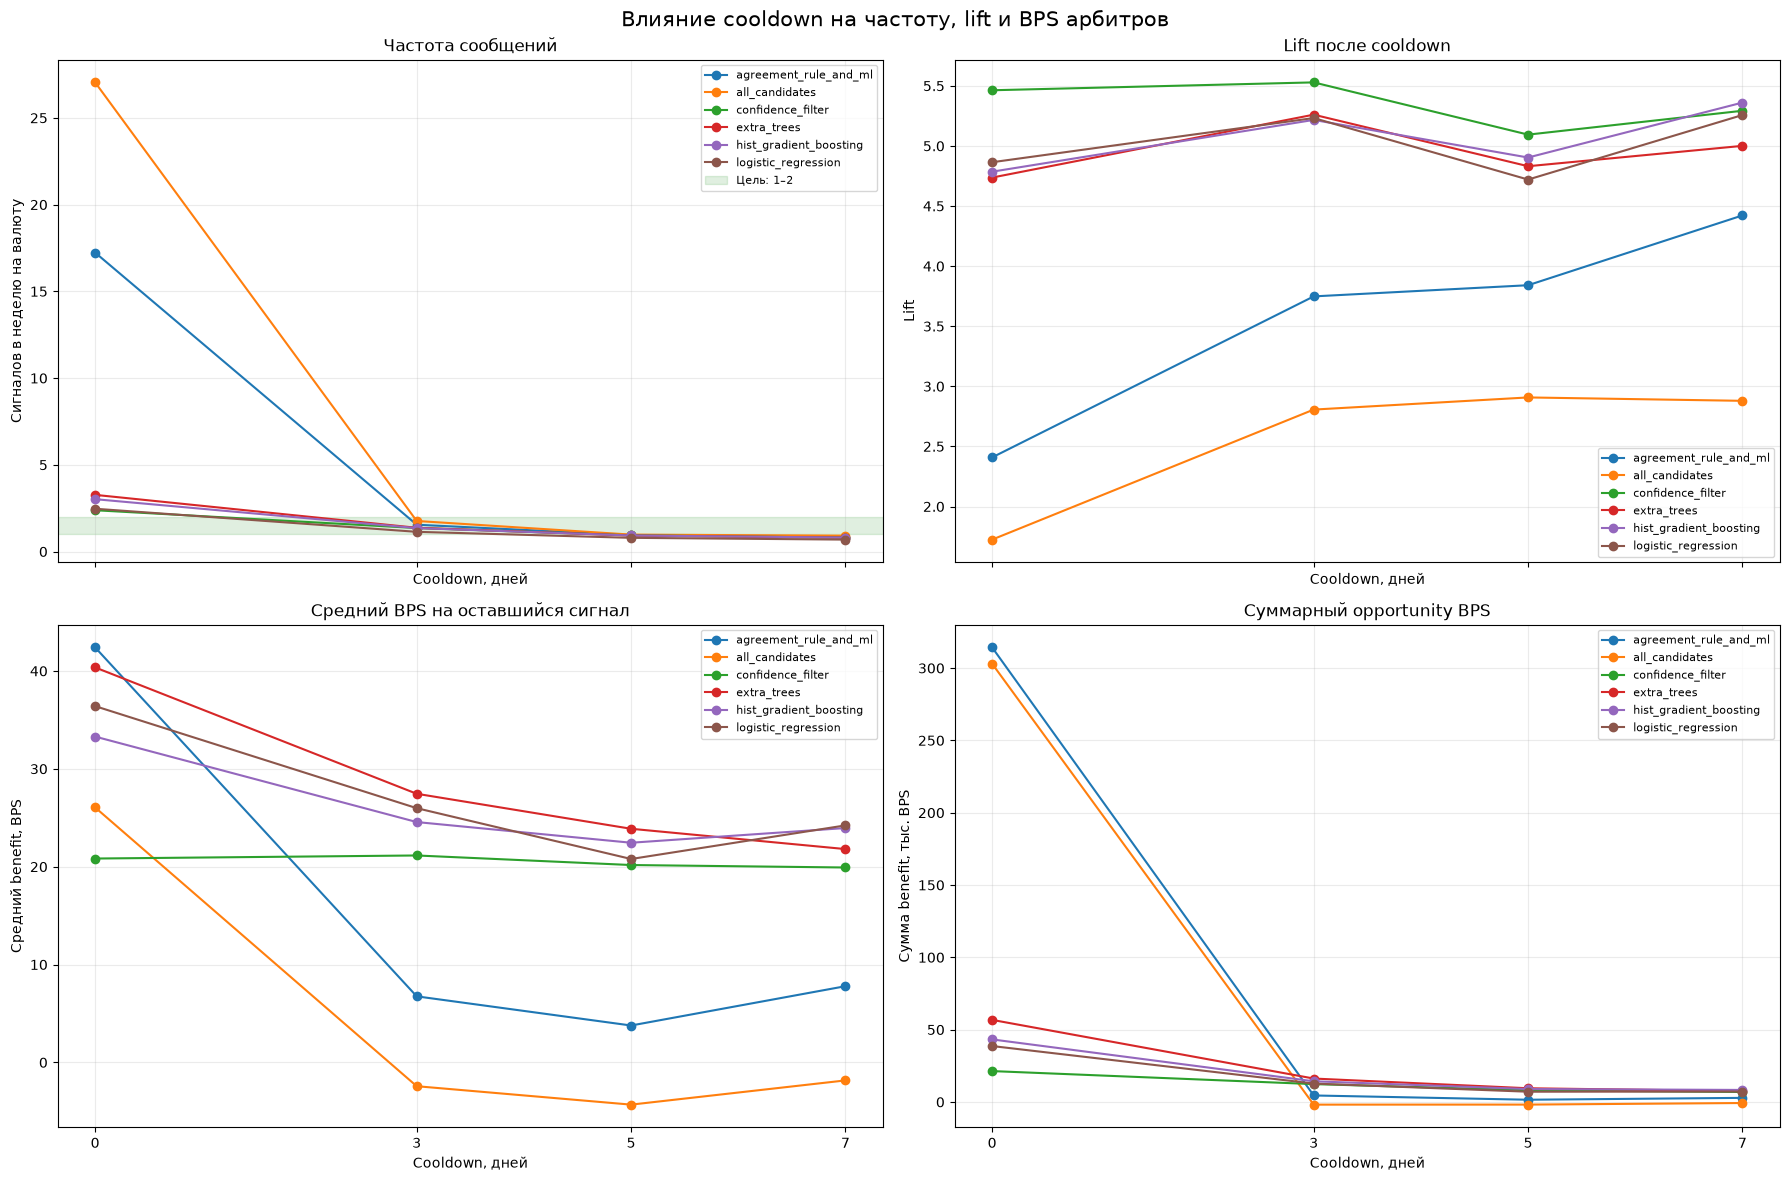

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)

for arbiter_name, data in arbiter_cooldown_comparison.groupby('arbiter'):
    data = data.sort_values('cooldown_days')
    axes[0, 0].plot(
        data['cooldown_days'], data['test_signals_per_week_per_currency'],
        marker='o', label=arbiter_name,
    )
    axes[0, 1].plot(
        data['cooldown_days'], data['test_lift'],
        marker='o', label=arbiter_name,
    )
    axes[1, 0].plot(
        data['cooldown_days'], data['test_mean_benefit_bps'],
        marker='o', label=arbiter_name,
    )
    axes[1, 1].plot(
        data['cooldown_days'], data['test_total_bps'] / 1000,
        marker='o', label=arbiter_name,
    )

axes[0, 0].axhspan(
    META_MIN_SIGNALS_PER_WEEK, META_MAX_SIGNALS_PER_WEEK,
    color='green', alpha=0.12, label='Цель: 1–2',
)
axes[0, 0].set_title('Частота сообщений')
axes[0, 0].set_ylabel('Сигналов в неделю на валюту')
axes[0, 1].set_title('Lift после cooldown')
axes[0, 1].set_ylabel('Lift')
axes[1, 0].set_title('Средний BPS на оставшийся сигнал')
axes[1, 0].set_ylabel('Средний benefit, BPS')
axes[1, 1].set_title('Суммарный opportunity BPS')
axes[1, 1].set_ylabel('Сумма benefit, тыс. BPS')

for ax in axes.flat:
    ax.set_xlabel('Cooldown, дней')
    ax.set_xticks(COOLDOWN_DAYS_TO_TEST)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle('Влияние cooldown на частоту, lift и BPS арбитров', fontsize=15)
plt.tight_layout()
fig.savefig(
    ARBITER_PLOT_DIR / 'arbiter_cooldown_comparison.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


### 7.5. Какой арбитр и cooldown приносят больше BPS

Сначала оставляем только комбинации, где **каждая валюта** попала в диапазон 1–2 сообщения в неделю. Затем сравниваем их по суммарному BPS, среднему BPS на сигнал и lift. Варианты с большим числом сообщений не побеждают только за счёт объёма.

`test_total_bps` — сумма оценённых выгод по сигналам, а не фактический P&L банка. Для денежного P&L нужны объёмы переводов, конверсия и маржа.

In [23]:
if 'arbiter_cooldown_comparison' not in globals():
    raise RuntimeError('Сначала запустите расчётную ячейку раздела 7.4')

cooldown_economics = arbiter_cooldown_comparison.copy()
backtest_weeks = period_weeks(evaluation_universe['available_at'])
backtest_currency_count = evaluation_universe['currency'].nunique()
cooldown_economics['bps_per_week_per_currency'] = (
    cooldown_economics['test_total_bps']
    / backtest_weeks
    / backtest_currency_count
)
cooldown_economics['economically_positive'] = (
    cooldown_economics['test_total_bps'].gt(0)
    & cooldown_economics['test_mean_benefit_bps'].gt(0)
)

cooldown_economic_ranking = (
    cooldown_economics.loc[
        cooldown_economics['all_currencies_frequency_ok']
        & cooldown_economics['economically_positive']
    ]
    .sort_values(
        ['test_total_bps', 'test_mean_benefit_bps', 'test_lift'],
        ascending=False,
    )
    .reset_index(drop=True)
)
cooldown_economic_ranking.insert(
    0, 'economic_rank', np.arange(1, len(cooldown_economic_ranking) + 1)
)

cooldown_mean_bps_matrix = (
    cooldown_economics
    .pivot(index='arbiter', columns='cooldown_days', values='test_mean_benefit_bps')
    .reindex(index=arbiter_order, columns=COOLDOWN_DAYS_TO_TEST)
)
cooldown_total_bps_matrix = (
    cooldown_economics
    .pivot(index='arbiter', columns='cooldown_days', values='test_total_bps')
    .reindex(index=arbiter_order, columns=COOLDOWN_DAYS_TO_TEST)
)

cumulative_parts = []
for (arbiter_name, cooldown_days), events in cooldown_events.items():
    _, rows = backtest_signal_stream(
        events, evaluation_universe=evaluation_universe
    )
    signals = rows.loc[rows['signal'], ['available_at', 'benefit_bps']].copy()
    signals['benefit_bps'] = pd.to_numeric(
        signals['benefit_bps'], errors='coerce'
    )
    daily = (
        signals.dropna(subset=['benefit_bps'])
        .groupby('available_at', as_index=False)
        .agg(
            daily_bps=('benefit_bps', 'sum'),
            daily_signal_count=('benefit_bps', 'size'),
        )
        .sort_values('available_at')
    )
    daily['cumulative_bps'] = daily['daily_bps'].cumsum()
    daily['cumulative_signal_count'] = daily['daily_signal_count'].cumsum()
    daily['cumulative_mean_bps'] = (
        daily['cumulative_bps'] / daily['cumulative_signal_count']
    )
    daily.insert(0, 'cooldown_days', cooldown_days)
    daily.insert(0, 'arbiter', arbiter_name)
    cumulative_parts.append(daily)

cooldown_cumulative_bps = pd.concat(cumulative_parts, ignore_index=True)
ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
cooldown_economic_ranking.to_csv(
    ARBITER_OUTPUT_DIR / 'cooldown_economic_ranking.csv', index=False
)
cooldown_cumulative_bps.to_csv(
    ARBITER_OUTPUT_DIR / 'cooldown_cumulative_bps.csv', index=False
)

ranking_columns = [
    'economic_rank', 'arbiter', 'cooldown_days',
    'test_signals_per_week_per_currency', 'test_total_bps',
    'test_mean_benefit_bps', 'bps_per_week_per_currency',
    'test_lift', 'test_positive_benefit_rate', 'min_currency_lift',
]
display(cooldown_economic_ranking[ranking_columns].round(3))


,economic_rank,arbiter,cooldown_days,test_signals_per_week_per_currency,test_total_bps,test_mean_benefit_bps,bps_per_week_per_currency,test_lift,test_positive_benefit_rate,min_currency_lift
0,1,extra_trees,3,1.372,16196.915,27.452,37.667,5.260,0.785,4.372
1,2,hist_gradient_boosting,3,1.353,14294.828,24.562,33.244,5.217,0.777,4.381
2,3,confidence_filter,3,1.358,12349.815,21.147,28.721,5.529,0.796,5.181
3,4,agreement_rule_and_ml,3,1.549,4496.494,6.751,10.457,3.748,0.641,3.293


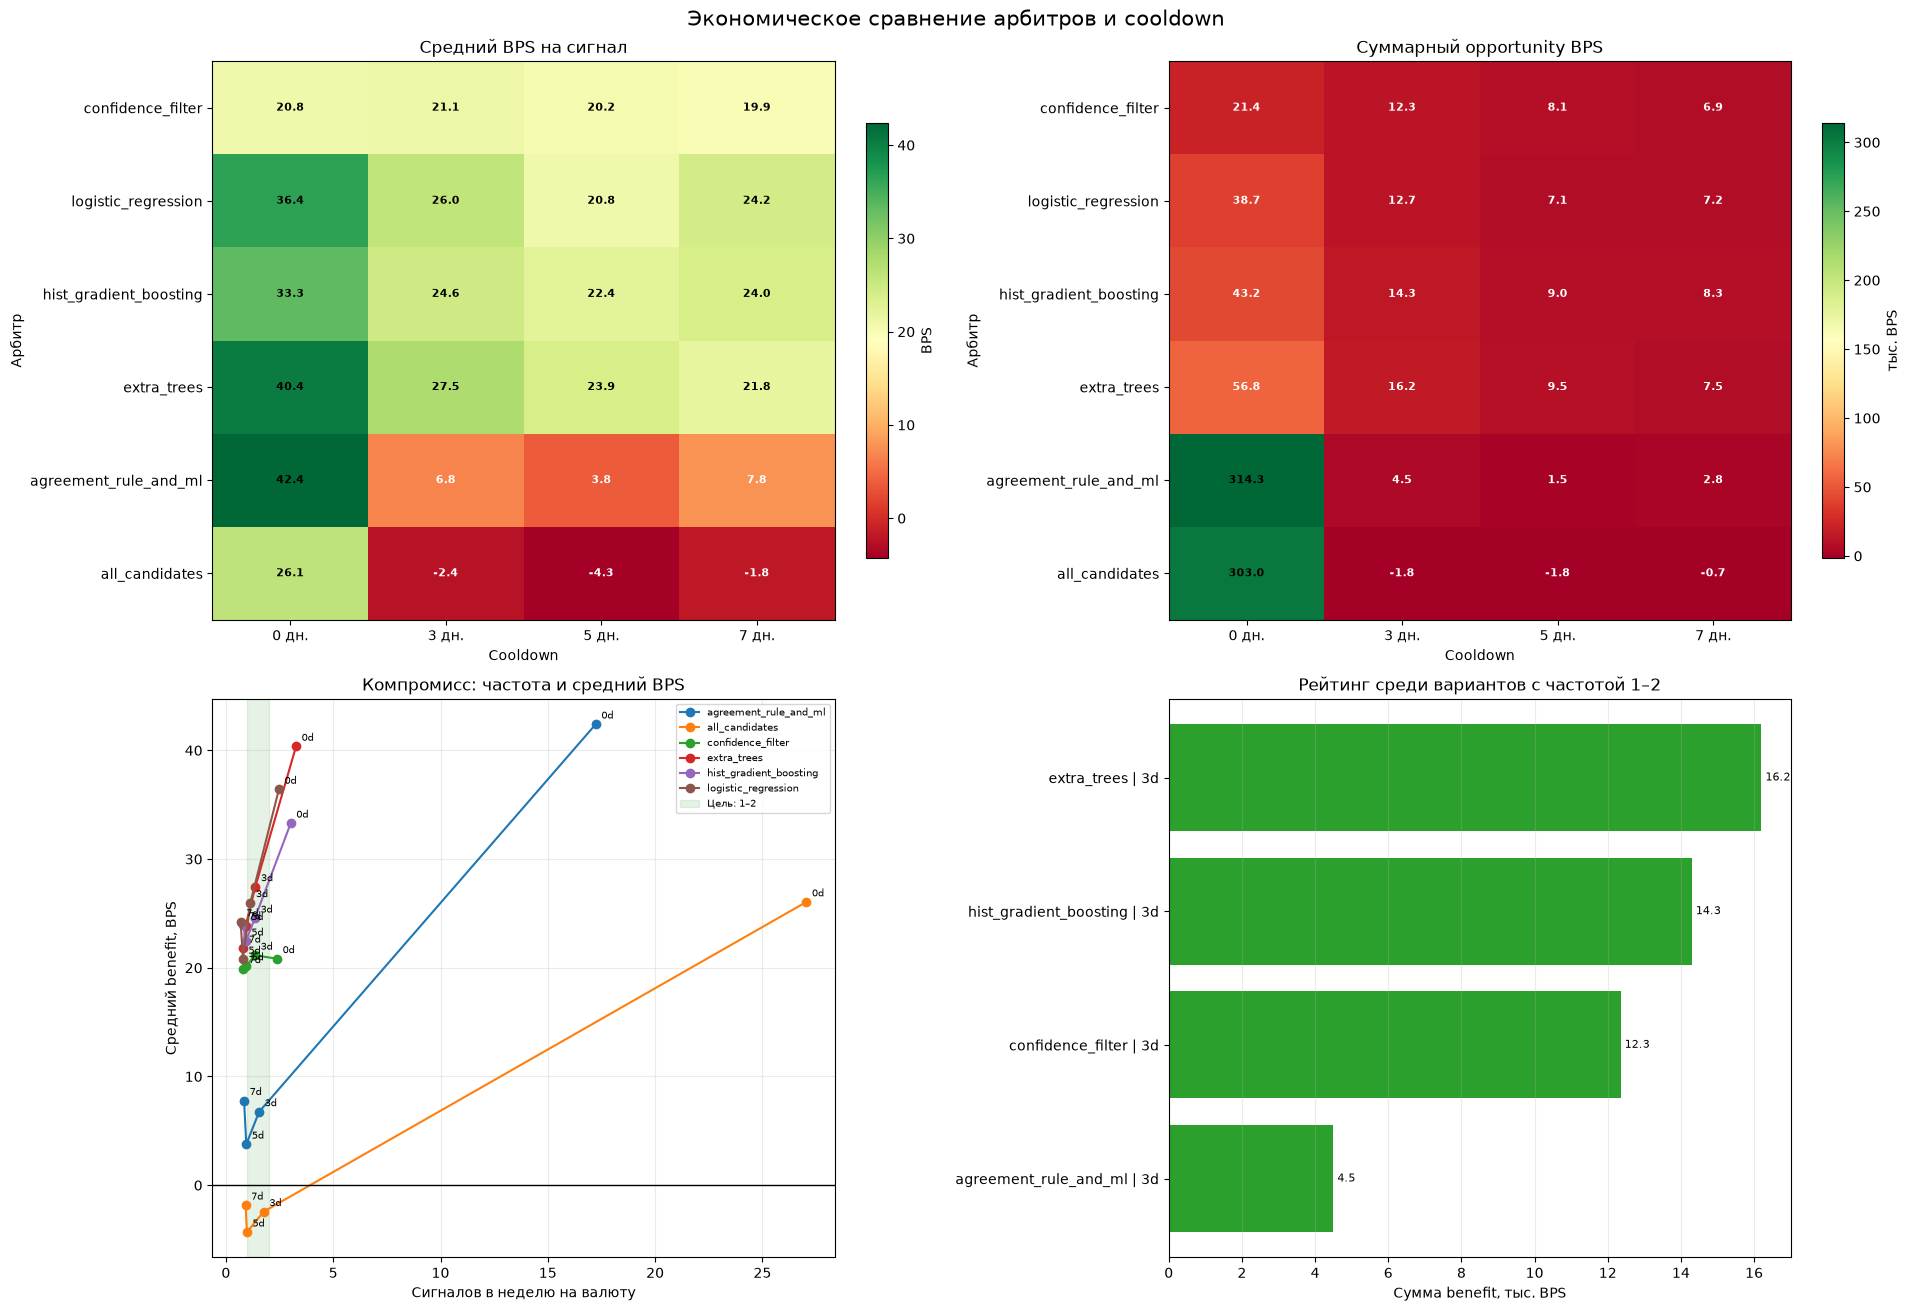

In [24]:
def annotated_heatmap(ax, matrix, title, colorbar_label, value_format):
    values = matrix.to_numpy(dtype=float)
    image = ax.imshow(values, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(matrix.columns)), labels=[f'{x} дн.' for x in matrix.columns])
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    ax.set_xlabel('Cooldown')
    ax.set_ylabel('Арбитр')
    ax.set_title(title)
    finite = values[np.isfinite(values)]
    midpoint = (finite.min() + finite.max()) / 2 if len(finite) else 0.0
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            label = '—' if not np.isfinite(value) else value_format.format(value)
            ax.text(
                column_index, row_index, label, ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white' if np.isfinite(value) and value < midpoint else 'black',
            )
    colorbar = ax.figure.colorbar(image, ax=ax, shrink=0.78)
    colorbar.set_label(colorbar_label)

fig, axes = plt.subplots(2, 2, figsize=(19, 13), constrained_layout=True)
annotated_heatmap(
    axes[0, 0], cooldown_mean_bps_matrix,
    'Средний BPS на сигнал', 'BPS', '{:.1f}',
)
annotated_heatmap(
    axes[0, 1], cooldown_total_bps_matrix / 1000,
    'Суммарный opportunity BPS', 'тыс. BPS', '{:.1f}',
)

for arbiter_name, data in cooldown_economics.groupby('arbiter'):
    data = data.sort_values('cooldown_days')
    axes[1, 0].plot(
        data['test_signals_per_week_per_currency'],
        data['test_mean_benefit_bps'],
        marker='o', label=arbiter_name,
    )
    for row in data.itertuples(index=False):
        axes[1, 0].annotate(
            f'{row.cooldown_days}d',
            (row.test_signals_per_week_per_currency, row.test_mean_benefit_bps),
            xytext=(4, 4), textcoords='offset points', fontsize=7,
        )
axes[1, 0].axvspan(
    META_MIN_SIGNALS_PER_WEEK, META_MAX_SIGNALS_PER_WEEK,
    color='green', alpha=0.10, label='Цель: 1–2',
)
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title('Компромисс: частота и средний BPS')
axes[1, 0].set_xlabel('Сигналов в неделю на валюту')
axes[1, 0].set_ylabel('Средний benefit, BPS')
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=7)

ranking_plot = cooldown_economic_ranking.sort_values('test_total_bps')
ranking_labels = (
    ranking_plot['arbiter'] + ' | ' + ranking_plot['cooldown_days'].astype(str) + 'd'
)
ranking_bars = axes[1, 1].barh(
    ranking_labels, ranking_plot['test_total_bps'] / 1000, color='tab:green'
)
axes[1, 1].bar_label(ranking_bars, fmt='%.1f', padding=3, fontsize=8)
axes[1, 1].set_title('Рейтинг среди вариантов с частотой 1–2')
axes[1, 1].set_xlabel('Сумма benefit, тыс. BPS')
axes[1, 1].grid(axis='x', alpha=0.25)

fig.suptitle('Экономическое сравнение арбитров и cooldown', fontsize=15)
fig.savefig(
    ARBITER_PLOT_DIR / 'cooldown_economic_comparison.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


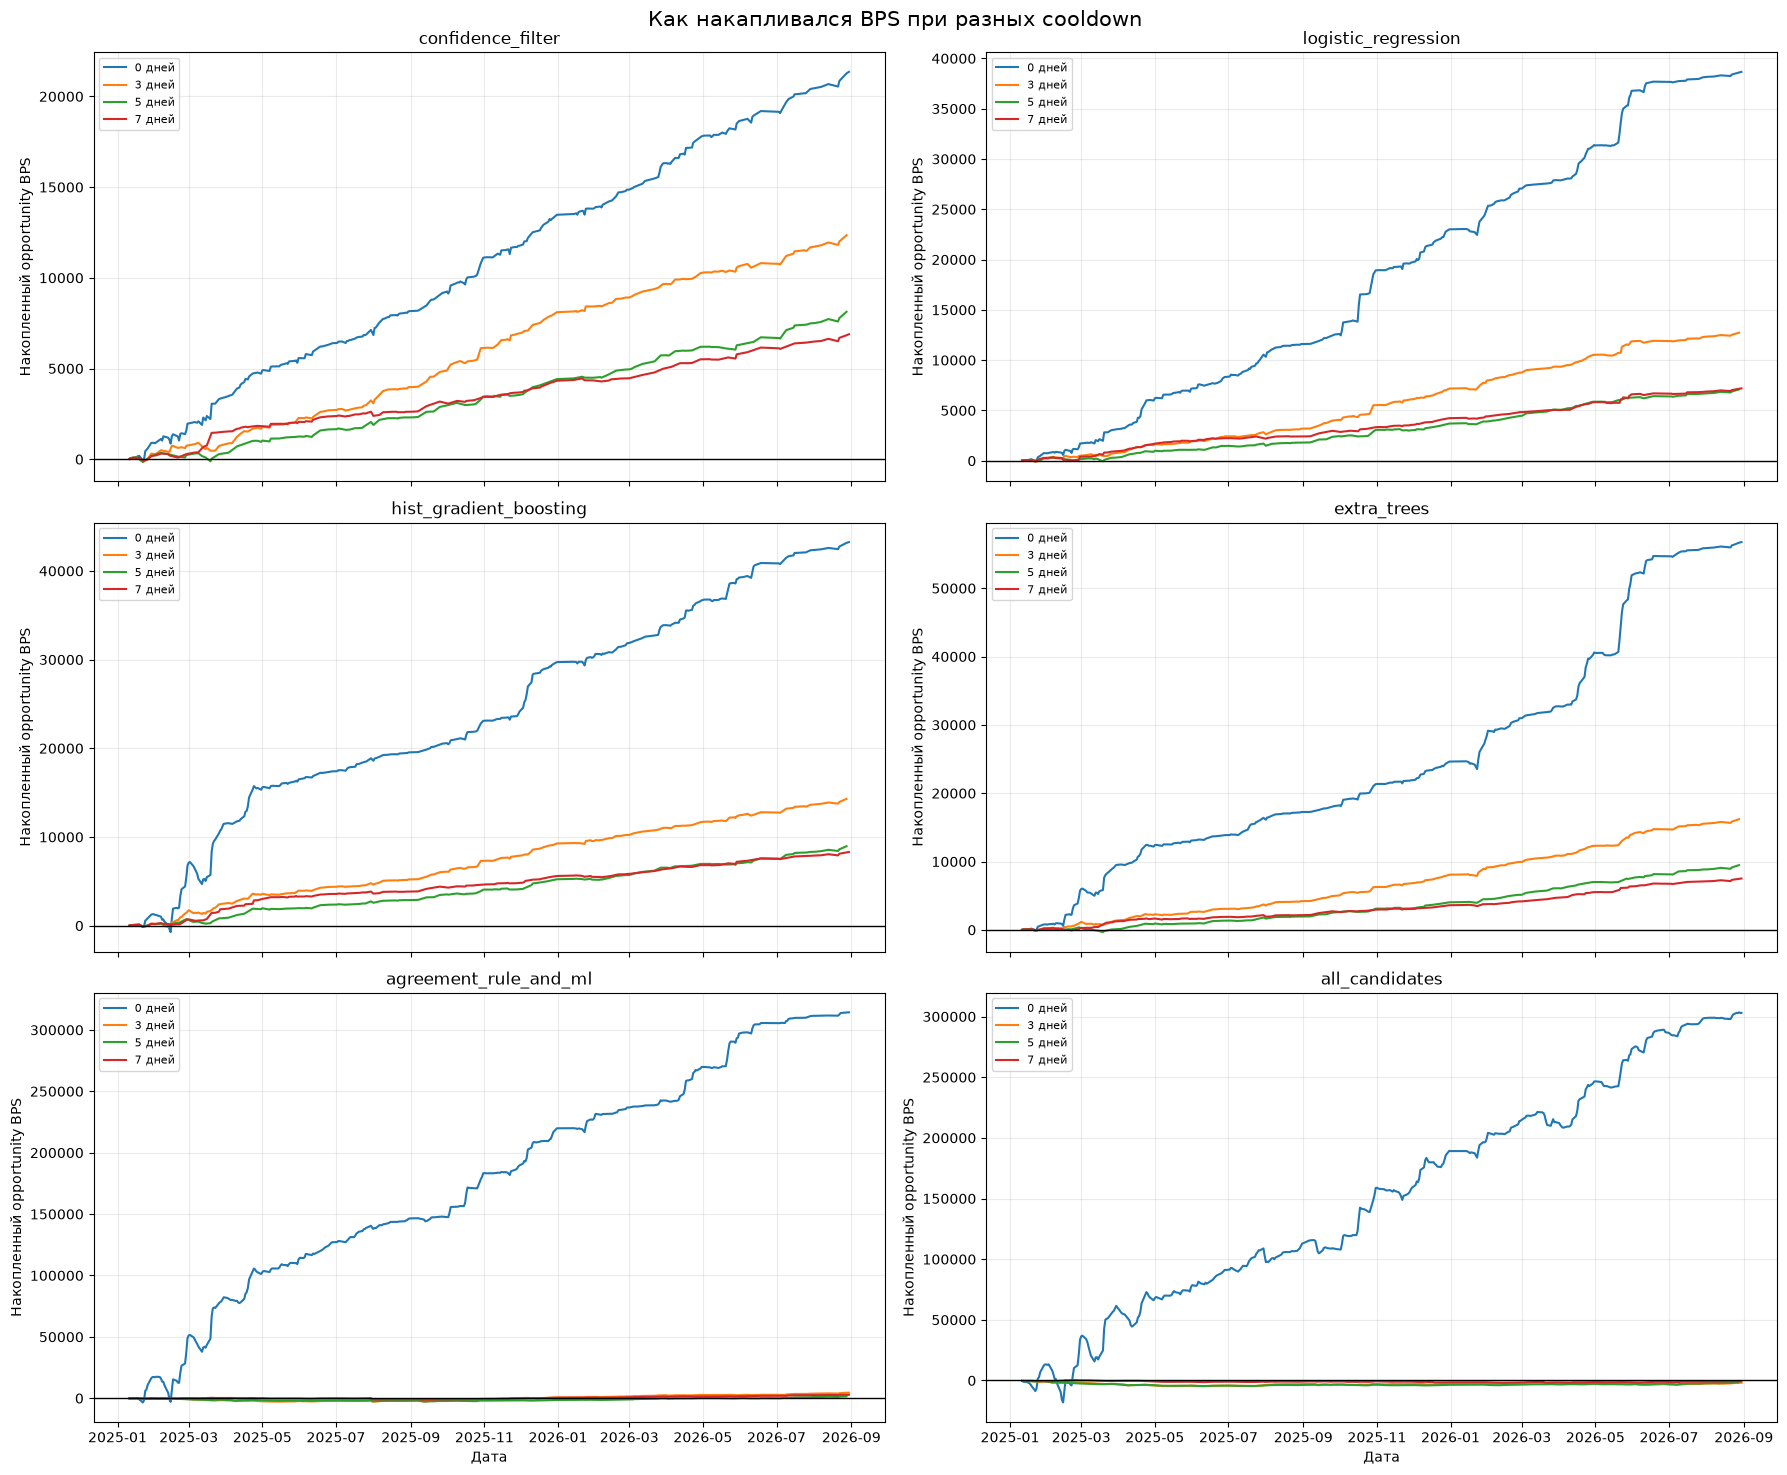

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True)
axes = axes.flatten()

for ax, arbiter_name in zip(axes, arbiter_order):
    arbiter_data = cooldown_cumulative_bps.loc[
        cooldown_cumulative_bps['arbiter'].eq(arbiter_name)
    ]
    for cooldown_days, data in arbiter_data.groupby('cooldown_days'):
        ax.plot(
            data['available_at'], data['cumulative_bps'],
            label=f'{cooldown_days} дней',
        )
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(arbiter_name)
    ax.set_ylabel('Накопленный opportunity BPS')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[-2:]:
    ax.set_xlabel('Дата')
fig.suptitle('Как накапливался BPS при разных cooldown', fontsize=15)
plt.tight_layout()
fig.savefig(
    ARBITER_PLOT_DIR / 'cooldown_cumulative_bps.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


### 7.6. Extra Trees, HistGradientBoosting и Confidence Filter по всем коридорам

Сравниваем три финалиста при одинаковом `cooldown = 3 дня`. Для каждого коридора показаны lift, precision, частота, средний/медианный/суммарный BPS и доля положительных сигналов.

Устойчивость lift проверяется двумя способами: (1) среднее, минимум и стандартное отклонение lift между валютами; (2) квартальный lift внутри каждой валюты. Чем меньше разброс и выше худший lift, тем устойчивее арбитр.

In [26]:
if 'cooldown_events' not in globals():
    raise RuntimeError('Сначала запустите расчётную ячейку раздела 7.4')

SELECTED_ARBITERS = (
    'extra_trees',
    'hist_gradient_boosting',
    'confidence_filter',
)
SELECTED_COOLDOWN_DAYS = 3

currency_parts = []
quarterly_parts = []
selected_backtest_parts = []

for arbiter_name in SELECTED_ARBITERS:
    events = cooldown_events[(arbiter_name, SELECTED_COOLDOWN_DAYS)]
    summary, rows = backtest_signal_stream(
        events, evaluation_universe=evaluation_universe
    )
    rows = rows.copy()
    rows.insert(0, 'arbiter', arbiter_name)
    selected_backtest_parts.append(rows)

    currency_metrics = summary.loc[
        summary['scope'].eq('currency'),
        ['currency', 'signal_count', 'precision', 'random_precision',
         'lift', 'signals_per_week', 'mean_benefit_bps',
         'positive_benefit_rate'],
    ].copy()
    currency_metrics = currency_metrics.rename(
        columns={'random_precision': 'baseline'}
    )
    signal_benefit = rows.loc[rows['signal'], ['currency', 'benefit_bps']].copy()
    signal_benefit['benefit_bps'] = pd.to_numeric(
        signal_benefit['benefit_bps'], errors='coerce'
    )
    benefit_metrics = (
        signal_benefit.dropna(subset=['benefit_bps'])
        .groupby('currency', as_index=False)
        .agg(
            median_benefit_bps=('benefit_bps', 'median'),
            total_benefit_bps=('benefit_bps', 'sum'),
        )
    )
    currency_metrics = currency_metrics.merge(
        benefit_metrics, on='currency', how='left', validate='one_to_one'
    )
    currency_metrics.insert(0, 'corridor', 'RUB_' + currency_metrics['currency'])
    currency_metrics.insert(0, 'arbiter', arbiter_name)
    currency_parts.append(currency_metrics)

    rows['quarter'] = pd.to_datetime(rows['available_at']).dt.to_period('Q').astype(str)
    for (currency, quarter), sample in rows.groupby(
        ['currency', 'quarter'], sort=True
    ):
        signal_count = int(sample['signal'].sum())
        true_positive = int((sample['signal'] & sample['target_value']).sum())
        precision = true_positive / signal_count if signal_count else 0.0
        baseline = float(sample['target_value'].mean()) if len(sample) else 0.0
        benefit = pd.to_numeric(
            sample.loc[sample['signal'], 'benefit_bps'], errors='coerce'
        ).dropna()
        quarterly_parts.append({
            'arbiter': arbiter_name,
            'currency': currency,
            'corridor': f'RUB_{currency}',
            'quarter': quarter,
            'observations': len(sample),
            'signal_count': signal_count,
            'precision': precision,
            'baseline': baseline,
            'lift': precision / baseline if baseline else np.nan,
            'mean_benefit_bps': float(benefit.mean()) if len(benefit) else np.nan,
            'total_benefit_bps': float(benefit.sum()) if len(benefit) else 0.0,
            'positive_benefit_rate': (
                float((benefit > 0).mean()) if len(benefit) else 0.0
            ),
        })

selected_arbiters_by_currency = pd.concat(currency_parts, ignore_index=True)
selected_arbiters_quarterly = pd.DataFrame(quarterly_parts)
selected_arbiters_backtest_rows = pd.concat(
    selected_backtest_parts, ignore_index=True
)

selected_arbiters_stability = (
    selected_arbiters_quarterly
    .groupby(['arbiter', 'currency', 'corridor'], as_index=False)
    .agg(
        quarters=('quarter', 'nunique'),
        quarterly_lift_mean=('lift', 'mean'),
        quarterly_lift_std=('lift', lambda values: values.std(ddof=0)),
        quarterly_lift_min=('lift', 'min'),
        quarterly_lift_max=('lift', 'max'),
        quarters_lift_above_1_share=(
            'lift', lambda values: float((values > 1).mean())
        ),
        quarters_with_signals_share=(
            'signal_count', lambda values: float((values > 0).mean())
        ),
    )
)

currency_summary = (
    selected_arbiters_by_currency
    .groupby('arbiter', as_index=False)
    .agg(
        currency_lift_mean=('lift', 'mean'),
        currency_lift_min=('lift', 'min'),
        currency_lift_std=('lift', lambda values: values.std(ddof=0)),
        mean_signals_per_week=('signals_per_week', 'mean'),
        min_signals_per_week=('signals_per_week', 'min'),
        max_signals_per_week=('signals_per_week', 'max'),
    )
)
time_summary = (
    selected_arbiters_stability
    .groupby('arbiter', as_index=False)
    .agg(
        mean_quarterly_lift_std=('quarterly_lift_std', 'mean'),
        worst_quarterly_lift=('quarterly_lift_min', 'min'),
        quarters_lift_above_1_share=(
            'quarters_lift_above_1_share', 'mean'
        ),
    )
)
global_benefit_summary = (
    selected_arbiters_backtest_rows.loc[
        selected_arbiters_backtest_rows['signal']
    ]
    .assign(benefit_bps=lambda frame: pd.to_numeric(
        frame['benefit_bps'], errors='coerce'
    ))
    .dropna(subset=['benefit_bps'])
    .groupby('arbiter', as_index=False)
    .agg(
        signal_count=('benefit_bps', 'size'),
        mean_benefit_bps=('benefit_bps', 'mean'),
        median_benefit_bps=('benefit_bps', 'median'),
        total_benefit_bps=('benefit_bps', 'sum'),
        positive_benefit_rate=(
            'benefit_bps', lambda values: float((values > 0).mean())
        ),
    )
)
selected_arbiters_summary = (
    currency_summary
    .merge(time_summary, on='arbiter', validate='one_to_one')
    .merge(global_benefit_summary, on='arbiter', validate='one_to_one')
    .set_index('arbiter')
    .reindex(SELECTED_ARBITERS)
    .reset_index()
)

ARBITER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARBITER_PLOT_DIR = ARBITER_OUTPUT_DIR / 'plots'
ARBITER_PLOT_DIR.mkdir(parents=True, exist_ok=True)
selected_arbiters_by_currency.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_by_currency.csv', index=False
)
selected_arbiters_quarterly.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_quarterly.csv', index=False
)
selected_arbiters_stability.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_lift_stability.csv', index=False
)
selected_arbiters_summary.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_summary.csv', index=False
)

display(selected_arbiters_summary.round(3))
display(selected_arbiters_by_currency.round(3))
display(selected_arbiters_stability.round(3))


,arbiter,currency_lift_mean,currency_lift_min,currency_lift_std,mean_signals_per_week,min_signals_per_week,max_signals_per_week,mean_quarterly_lift_std,worst_quarterly_lift,quarters_lift_above_1_share,signal_count,mean_benefit_bps,median_benefit_bps,total_benefit_bps,positive_benefit_rate
0,extra_trees,5.255,4.372,0.590,1.372,1.279,1.442,4.567,1.974,1.0,590,27.452,20.895,16196.915,0.785
1,hist_gradient_boosting,5.224,4.381,0.636,1.353,1.233,1.442,4.745,1.786,1.0,582,24.562,18.664,14294.828,0.777
2,confidence_filter,5.529,5.181,0.372,1.358,1.302,1.430,4.576,2.616,1.0,584,21.147,18.310,12349.815,0.796


,arbiter,corridor,currency,signal_count,precision,baseline,lift,signals_per_week,mean_benefit_bps,positive_benefit_rate,median_benefit_bps,total_benefit_bps
0,extra_trees,RUB_AMD,AMD,110,0.509,0.105,4.851,1.279,20.219,0.773,18.090,2224.111
1,extra_trees,RUB_KGS,KGS,120,0.550,0.103,5.355,1.395,20.193,0.767,14.427,2423.180
2,extra_trees,RUB_KZT,KZT,121,0.636,0.105,6.050,1.407,30.652,0.818,25.573,3708.945
3,extra_trees,RUB_TJS,TJS,124,0.556,0.099,5.648,1.442,33.634,0.790,24.444,4170.666
4,extra_trees,RUB_UZS,UZS,115,0.470,0.107,4.372,1.337,31.913,0.774,25.423,3670.012
5,hist_gradient_boosting,RUB_AMD,AMD,106,0.519,0.105,4.945,1.233,18.447,0.764,18.090,1955.430
6,hist_gradient_boosting,RUB_KGS,KGS,117,0.556,0.103,5.409,1.360,15.994,0.761,13.697,1871.308
7,hist_gradient_boosting,RUB_KZT,KZT,116,0.664,0.105,6.311,1.349,28.844,0.810,22.658,3345.962
8,hist_gradient_boosting,RUB_TJS,TJS,124,0.500,0.099,5.075,1.442,27.203,0.774,20.365,3373.183
9,hist_gradient_boosting,RUB_UZS,UZS,119,0.471,0.107,4.381,1.384,31.504,0.773,21.699,3748.945


,arbiter,currency,corridor,quarters,quarterly_lift_mean,quarterly_lift_std,quarterly_lift_min,quarterly_lift_max,quarters_lift_above_1_share,quarters_with_signals_share
0,confidence_filter,AMD,RUB_AMD,7,6.820,4.130,3.699,15.926,1.0,1.0
1,confidence_filter,KGS,RUB_KGS,7,6.173,3.059,3.043,13.030,1.0,1.0
2,confidence_filter,KZT,RUB_KZT,7,8.624,7.098,3.128,25.294,1.0,1.0
3,confidence_filter,TJS,RUB_TJS,7,7.542,4.876,2.616,16.250,1.0,1.0
4,confidence_filter,UZS,RUB_UZS,7,6.474,3.718,3.062,14.145,1.0,1.0
5,extra_trees,AMD,RUB_AMD,7,6.455,4.286,2.985,15.926,1.0,1.0
6,extra_trees,KGS,RUB_KGS,7,6.457,3.210,3.213,13.030,1.0,1.0
7,extra_trees,KZT,RUB_KZT,7,8.551,7.093,3.538,25.294,1.0,1.0
8,extra_trees,TJS,RUB_TJS,7,7.481,4.757,2.857,16.250,1.0,1.0
9,extra_trees,UZS,RUB_UZS,7,5.560,3.488,1.974,12.932,1.0,1.0


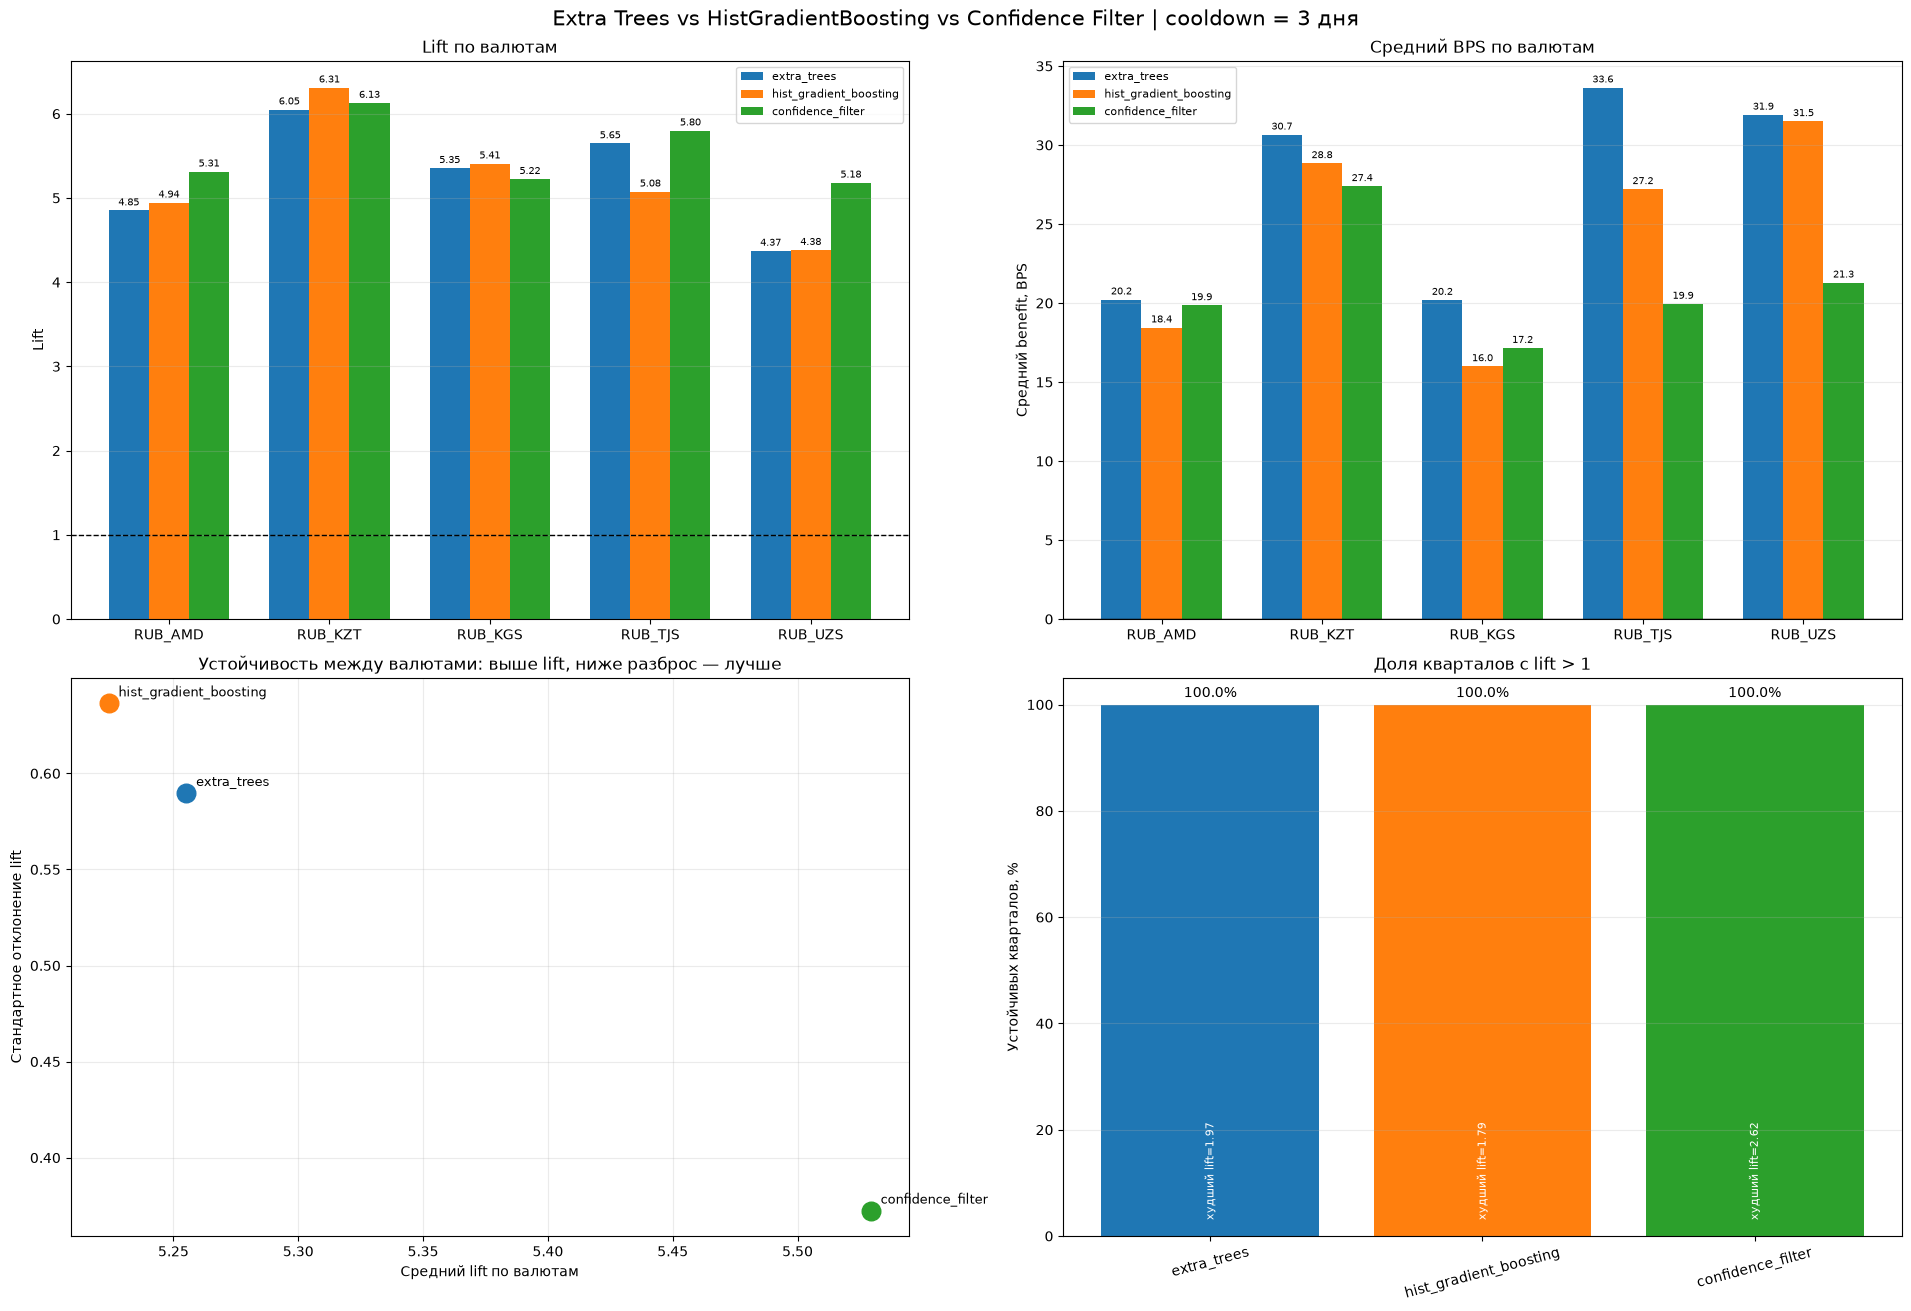

In [27]:
currency_order = list(PRODUCTION_CURRENCIES)
positions = np.arange(len(currency_order))
width = 0.25
colors = dict(zip(SELECTED_ARBITERS, ('tab:blue', 'tab:orange', 'tab:green')))
fig, axes = plt.subplots(2, 2, figsize=(19, 13), constrained_layout=True)

for index, arbiter_name in enumerate(SELECTED_ARBITERS):
    data = (
        selected_arbiters_by_currency
        .loc[lambda frame: frame['arbiter'].eq(arbiter_name)]
        .set_index('currency')
        .reindex(currency_order)
    )
    offset = (index - 1) * width
    lift_bars = axes[0, 0].bar(
        positions + offset, data['lift'], width,
        label=arbiter_name, color=colors[arbiter_name],
    )
    bps_bars = axes[0, 1].bar(
        positions + offset, data['mean_benefit_bps'], width,
        label=arbiter_name, color=colors[arbiter_name],
    )
    axes[0, 0].bar_label(lift_bars, fmt='%.2f', padding=2, fontsize=7)
    axes[0, 1].bar_label(bps_bars, fmt='%.1f', padding=2, fontsize=7)

axes[0, 0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Lift по валютам')
axes[0, 0].set_ylabel('Lift')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Средний BPS по валютам')
axes[0, 1].set_ylabel('Средний benefit, BPS')
for ax in axes[0]:
    ax.set_xticks(positions, labels=[f'RUB_{x}' for x in currency_order])
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

for row in selected_arbiters_summary.itertuples(index=False):
    axes[1, 0].scatter(
        row.currency_lift_mean, row.currency_lift_std,
        s=180, color=colors[row.arbiter], label=row.arbiter,
    )
    axes[1, 0].annotate(
        row.arbiter, (row.currency_lift_mean, row.currency_lift_std),
        xytext=(7, 5), textcoords='offset points', fontsize=9,
    )
axes[1, 0].set_title('Устойчивость между валютами: выше lift, ниже разброс — лучше')
axes[1, 0].set_xlabel('Средний lift по валютам')
axes[1, 0].set_ylabel('Стандартное отклонение lift')
axes[1, 0].grid(alpha=0.25)

stability_plot = selected_arbiters_summary.set_index('arbiter').loc[
    list(SELECTED_ARBITERS)
]
stability_bars = axes[1, 1].bar(
    stability_plot.index,
    100 * stability_plot['quarters_lift_above_1_share'],
    color=[colors[name] for name in stability_plot.index],
)
axes[1, 1].bar_label(stability_bars, fmt='%.1f%%', padding=3)
for index, row in enumerate(stability_plot.itertuples()):
    axes[1, 1].text(
        index, 3, f'худший lift={row.worst_quarterly_lift:.2f}',
        ha='center', va='bottom', rotation=90, color='white', fontsize=8,
    )
axes[1, 1].set_ylim(0, 105)
axes[1, 1].set_title('Доля кварталов с lift > 1')
axes[1, 1].set_ylabel('Устойчивых кварталов, %')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(axis='y', alpha=0.25)

fig.suptitle(
    'Extra Trees vs HistGradientBoosting vs Confidence Filter | cooldown = 3 дня',
    fontsize=15,
)
fig.savefig(
    ARBITER_PLOT_DIR / 'selected_arbiters_currency_comparison.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


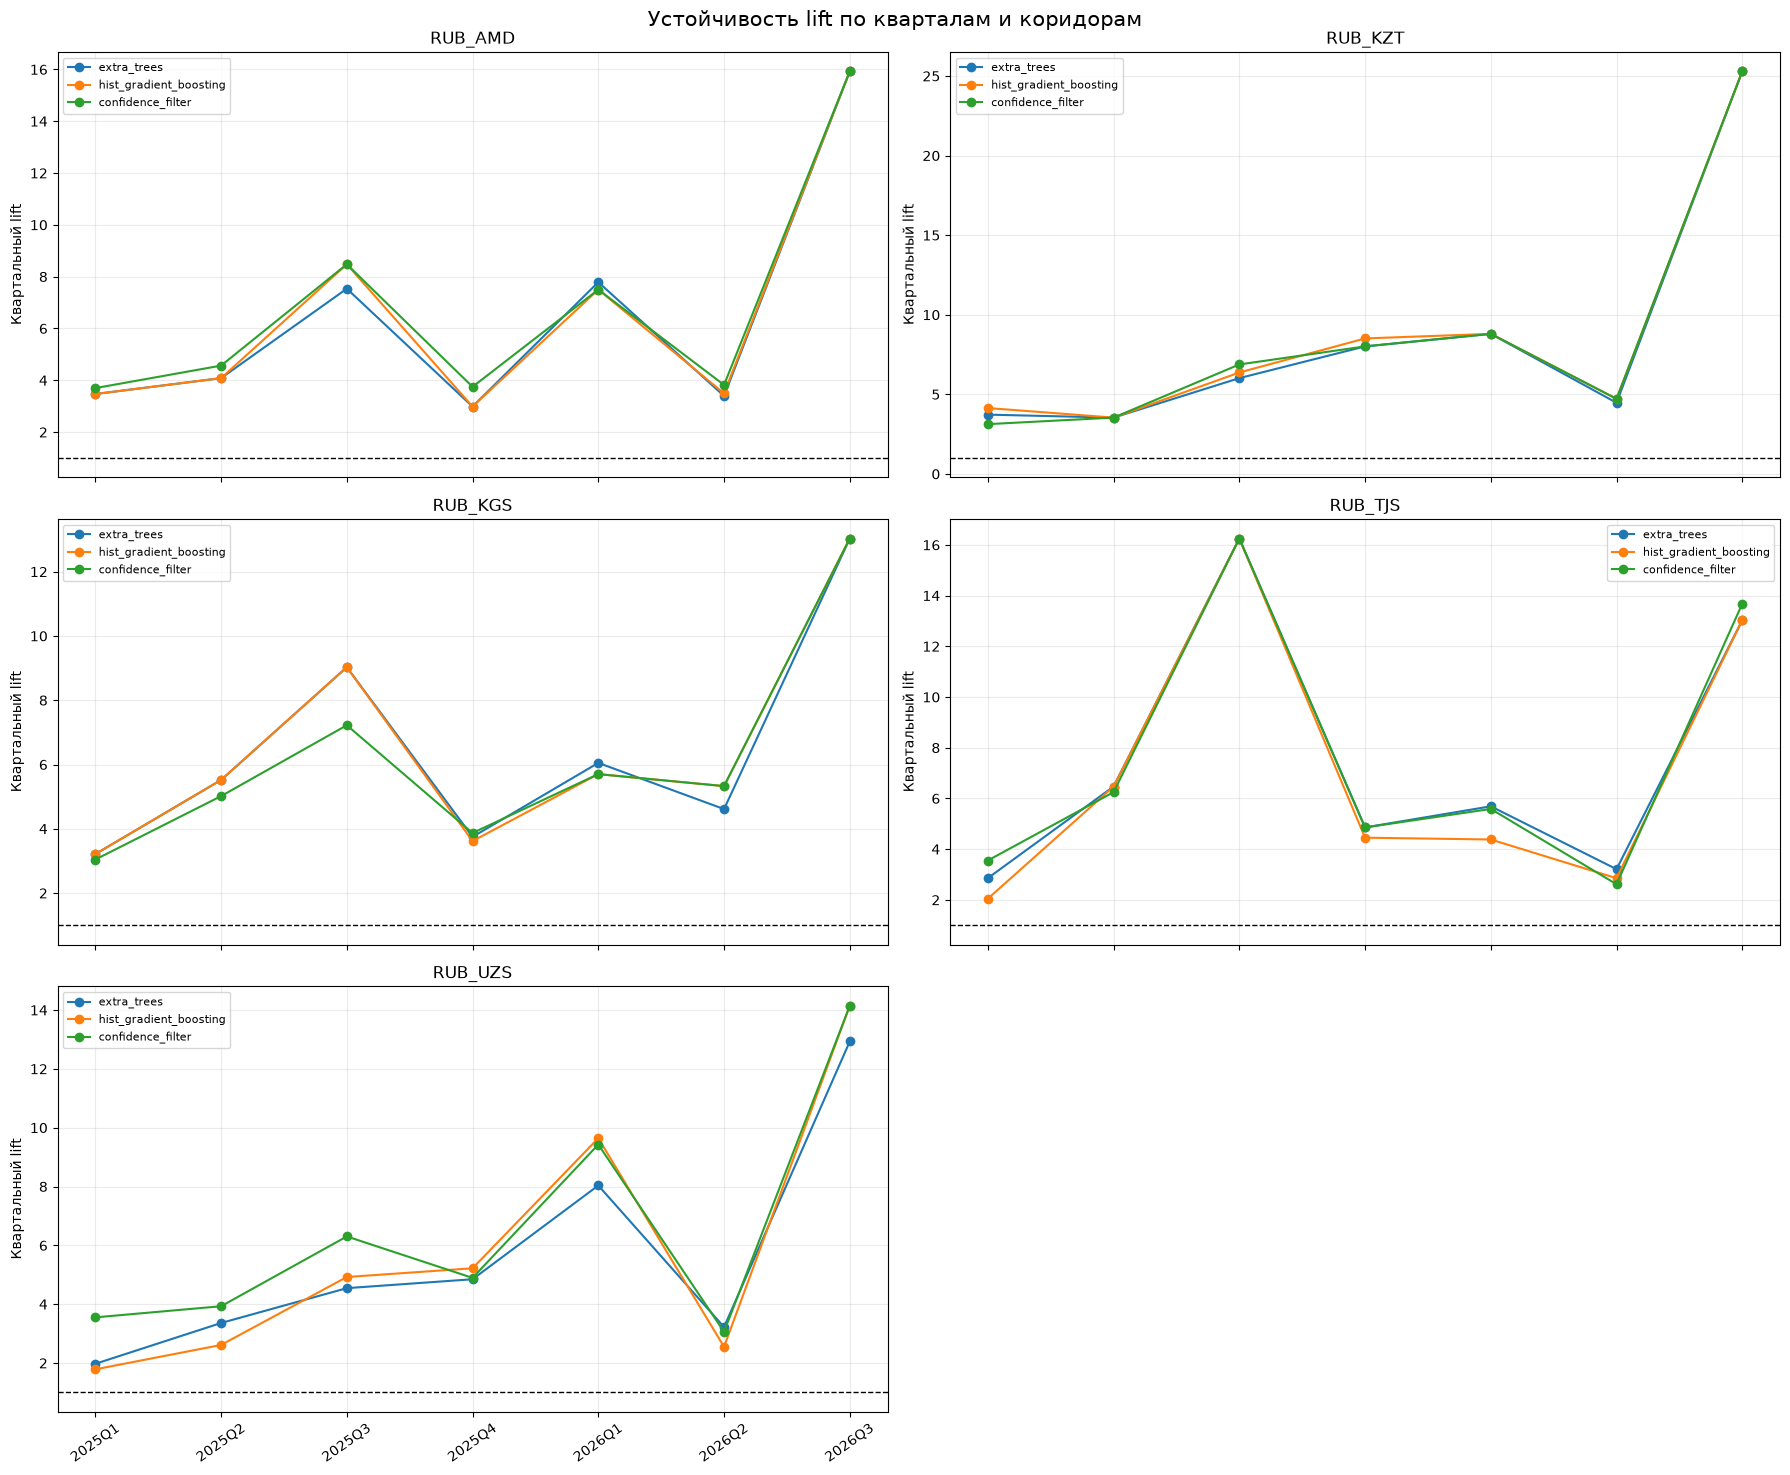

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True)
axes = axes.flatten()

for ax, currency in zip(axes, currency_order):
    currency_data = selected_arbiters_quarterly.loc[
        selected_arbiters_quarterly['currency'].eq(currency)
    ]
    for arbiter_name in SELECTED_ARBITERS:
        data = (
            currency_data.loc[
                currency_data['arbiter'].eq(arbiter_name)
            ]
            .sort_values('quarter')
        )
        ax.plot(
            data['quarter'], data['lift'], marker='o',
            label=arbiter_name, color=colors[arbiter_name],
        )
    ax.axhline(1, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'RUB_{currency}')
    ax.set_ylabel('Квартальный lift')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=35)

for ax in axes[len(currency_order):]:
    ax.axis('off')
fig.suptitle('Устойчивость lift по кварталам и коридорам', fontsize=15)
plt.tight_layout()
fig.savefig(
    ARBITER_PLOT_DIR / 'selected_arbiters_quarterly_lift.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


### 7.7. Статистическая устойчивость: парный блочный bootstrap

Квартальные срезы выше — описательная проверка: они показывают, меняется ли lift во времени и между валютами. Bootstrap отвечает на другой вопрос: насколько точна оценка lift и можно ли считать различия между арбитрами устойчивыми, а не случайными.

Обычный bootstrap отдельных строк здесь некорректен, потому что соседние даты и несколько targets одной даты зависимы. Поэтому пересэмплируем непрерывные блоки по 4 недели. Один и тот же набор блоков применяется ко всем арбитрам — сравнение получается парным. Интервалы условны на уже обученных моделях: на каждой итерации модели и thresholds заново не обучаются.

In [29]:
from itertools import combinations

if 'selected_arbiters_backtest_rows' not in globals():
    raise RuntimeError('Сначала запустите расчётную ячейку раздела 7.6')

BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_BLOCK_WEEKS = 4
BOOTSTRAP_SEED = 42

bootstrap_source = selected_arbiters_backtest_rows.copy()
bootstrap_source['available_at'] = pd.to_datetime(bootstrap_source['available_at'])
bootstrap_source['week'] = (
    bootstrap_source['available_at'].dt.to_period('W-SUN').dt.start_time
)
bootstrap_source['_observations'] = 1
bootstrap_source['_positives'] = bootstrap_source['target_value'].astype(int)
bootstrap_source['_signals'] = bootstrap_source['signal'].astype(int)
bootstrap_source['_true_positives'] = (
    bootstrap_source['signal'] & bootstrap_source['target_value']
).astype(int)
numeric_benefit = pd.to_numeric(bootstrap_source['benefit_bps'], errors='coerce')
valid_signal_benefit = bootstrap_source['signal'] & numeric_benefit.notna()
bootstrap_source['_benefit_sum'] = np.where(
    valid_signal_benefit, numeric_benefit, 0.0
)
bootstrap_source['_benefit_count'] = valid_signal_benefit.astype(int)

BOOTSTRAP_STAT_COLUMNS = [
    '_observations', '_positives', '_signals', '_true_positives',
    '_benefit_sum', '_benefit_count',
]
weekly_by_currency = (
    bootstrap_source
    .groupby(['arbiter', 'currency', 'week'], as_index=False)[BOOTSTRAP_STAT_COLUMNS]
    .sum()
)
weekly_all = (
    bootstrap_source
    .groupby(['arbiter', 'week'], as_index=False)[BOOTSTRAP_STAT_COLUMNS]
    .sum()
    .assign(currency='ALL')
)
bootstrap_weekly = pd.concat(
    [weekly_by_currency, weekly_all], ignore_index=True
)

bootstrap_weeks = np.array(sorted(bootstrap_source['week'].unique()))
week_count = len(bootstrap_weeks)
rng = np.random.default_rng(BOOTSTRAP_SEED)
block_count = int(np.ceil(week_count / BOOTSTRAP_BLOCK_WEEKS))
bootstrap_weights = np.zeros((BOOTSTRAP_REPEATS, week_count), dtype=int)
for repeat in range(BOOTSTRAP_REPEATS):
    starts = rng.integers(0, week_count, size=block_count)
    sampled_positions = np.concatenate([
        (np.arange(start, start + BOOTSTRAP_BLOCK_WEEKS) % week_count)
        for start in starts
    ])[:week_count]
    bootstrap_weights[repeat] = np.bincount(
        sampled_positions, minlength=week_count
    )

def metrics_from_totals(totals):
    observations = totals[:, 0]
    positives = totals[:, 1]
    signals = totals[:, 2]
    true_positives = totals[:, 3]
    benefit_sum = totals[:, 4]
    benefit_count = totals[:, 5]
    precision = np.divide(
        true_positives, signals,
        out=np.zeros_like(true_positives, dtype=float), where=signals > 0,
    )
    baseline = np.divide(
        positives, observations,
        out=np.zeros_like(positives, dtype=float), where=observations > 0,
    )
    lift = np.divide(
        precision, baseline,
        out=np.full_like(precision, np.nan, dtype=float), where=baseline > 0,
    )
    mean_bps = np.divide(
        benefit_sum, benefit_count,
        out=np.full_like(benefit_sum, np.nan, dtype=float), where=benefit_count > 0,
    )
    return precision, baseline, lift, mean_bps

bootstrap_parts = []
point_rows = []
for (arbiter_name, currency), group in bootstrap_weekly.groupby(
    ['arbiter', 'currency'], sort=True
):
    matrix = (
        group.set_index('week')[BOOTSTRAP_STAT_COLUMNS]
        .reindex(bootstrap_weeks, fill_value=0)
        .to_numpy(dtype=float)
    )
    sampled_totals = bootstrap_weights @ matrix
    precision, baseline, lift, mean_bps = metrics_from_totals(sampled_totals)
    bootstrap_parts.append(pd.DataFrame({
        'repeat': np.arange(BOOTSTRAP_REPEATS),
        'arbiter': arbiter_name,
        'currency': currency,
        'lift': lift,
        'precision': precision,
        'baseline': baseline,
        'mean_benefit_bps': mean_bps,
    }))
    point_precision, point_baseline, point_lift, point_bps = metrics_from_totals(
        matrix.sum(axis=0, keepdims=True)
    )
    point_rows.append({
        'arbiter': arbiter_name,
        'currency': currency,
        'lift': point_lift[0],
        'precision': point_precision[0],
        'baseline': point_baseline[0],
        'mean_benefit_bps': point_bps[0],
    })

arbiter_bootstrap_samples = pd.concat(bootstrap_parts, ignore_index=True)
arbiter_bootstrap_points = pd.DataFrame(point_rows)

def q025(values):
    return values.quantile(0.025)

def q975(values):
    return values.quantile(0.975)

arbiter_bootstrap_summary = (
    arbiter_bootstrap_samples
    .groupby(['arbiter', 'currency'], as_index=False)
    .agg(
        lift_bootstrap_mean=('lift', 'mean'),
        lift_bootstrap_std=('lift', 'std'),
        lift_ci_low=('lift', q025),
        lift_ci_high=('lift', q975),
        mean_bps_bootstrap_mean=('mean_benefit_bps', 'mean'),
        mean_bps_ci_low=('mean_benefit_bps', q025),
        mean_bps_ci_high=('mean_benefit_bps', q975),
    )
    .merge(
        arbiter_bootstrap_points, on=['arbiter', 'currency'],
        how='left', validate='one_to_one',
    )
)

overall_lift_samples = (
    arbiter_bootstrap_samples.loc[
        arbiter_bootstrap_samples['currency'].eq('ALL')
    ]
    .pivot(index='repeat', columns='arbiter', values='lift')
    .reindex(columns=SELECTED_ARBITERS)
)
probability_best = (
    overall_lift_samples.idxmax(axis=1)
    .value_counts(normalize=True)
    .reindex(SELECTED_ARBITERS, fill_value=0.0)
    .rename('probability_best_lift')
    .rename_axis('arbiter')
    .reset_index()
)
arbiter_bootstrap_overall = (
    arbiter_bootstrap_summary.loc[
        arbiter_bootstrap_summary['currency'].eq('ALL')
    ]
    .merge(probability_best, on='arbiter', validate='one_to_one')
    .set_index('arbiter').reindex(SELECTED_ARBITERS).reset_index()
)

pairwise_rows = []
for arbiter_a, arbiter_b in combinations(SELECTED_ARBITERS, 2):
    delta = overall_lift_samples[arbiter_a] - overall_lift_samples[arbiter_b]
    point = (
        arbiter_bootstrap_points.loc[
            arbiter_bootstrap_points['currency'].eq('ALL')
        ].set_index('arbiter')['lift']
    )
    pairwise_rows.append({
        'arbiter_a': arbiter_a,
        'arbiter_b': arbiter_b,
        'point_lift_difference_a_minus_b': point[arbiter_a] - point[arbiter_b],
        'bootstrap_mean_difference': delta.mean(),
        'difference_ci_low': delta.quantile(0.025),
        'difference_ci_high': delta.quantile(0.975),
        'probability_a_has_higher_lift': float((delta > 0).mean()),
    })
arbiter_bootstrap_pairwise = pd.DataFrame(pairwise_rows)

arbiter_bootstrap_summary.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_bootstrap_by_currency.csv', index=False
)
arbiter_bootstrap_overall.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_bootstrap_overall.csv', index=False
)
arbiter_bootstrap_pairwise.to_csv(
    ARBITER_OUTPUT_DIR / 'selected_arbiters_bootstrap_pairwise.csv', index=False
)

display(arbiter_bootstrap_overall.round(3))
display(arbiter_bootstrap_pairwise.round(3))


,arbiter,currency,lift_bootstrap_mean,lift_bootstrap_std,lift_ci_low,lift_ci_high,mean_bps_bootstrap_mean,mean_bps_ci_low,mean_bps_ci_high,lift,precision,baseline,mean_benefit_bps,probability_best_lift
0,extra_trees,ALL,5.320,0.683,4.157,6.807,27.394,22.127,32.939,5.260,0.546,0.104,27.452,0.002
1,hist_gradient_boosting,ALL,5.278,0.705,4.051,6.785,24.481,19.864,29.132,5.217,0.541,0.104,24.562,0.004
2,confidence_filter,ALL,5.586,0.685,4.381,7.053,21.128,16.583,25.658,5.529,0.574,0.104,21.147,0.995


,arbiter_a,arbiter_b,point_lift_difference_a_minus_b,bootstrap_mean_difference,difference_ci_low,difference_ci_high,probability_a_has_higher_lift
0,extra_trees,hist_gradient_boosting,0.044,0.042,-0.128,0.219,0.683
1,extra_trees,confidence_filter,-0.269,-0.266,-0.461,-0.084,0.002
2,hist_gradient_boosting,confidence_filter,-0.312,-0.308,-0.527,-0.094,0.004


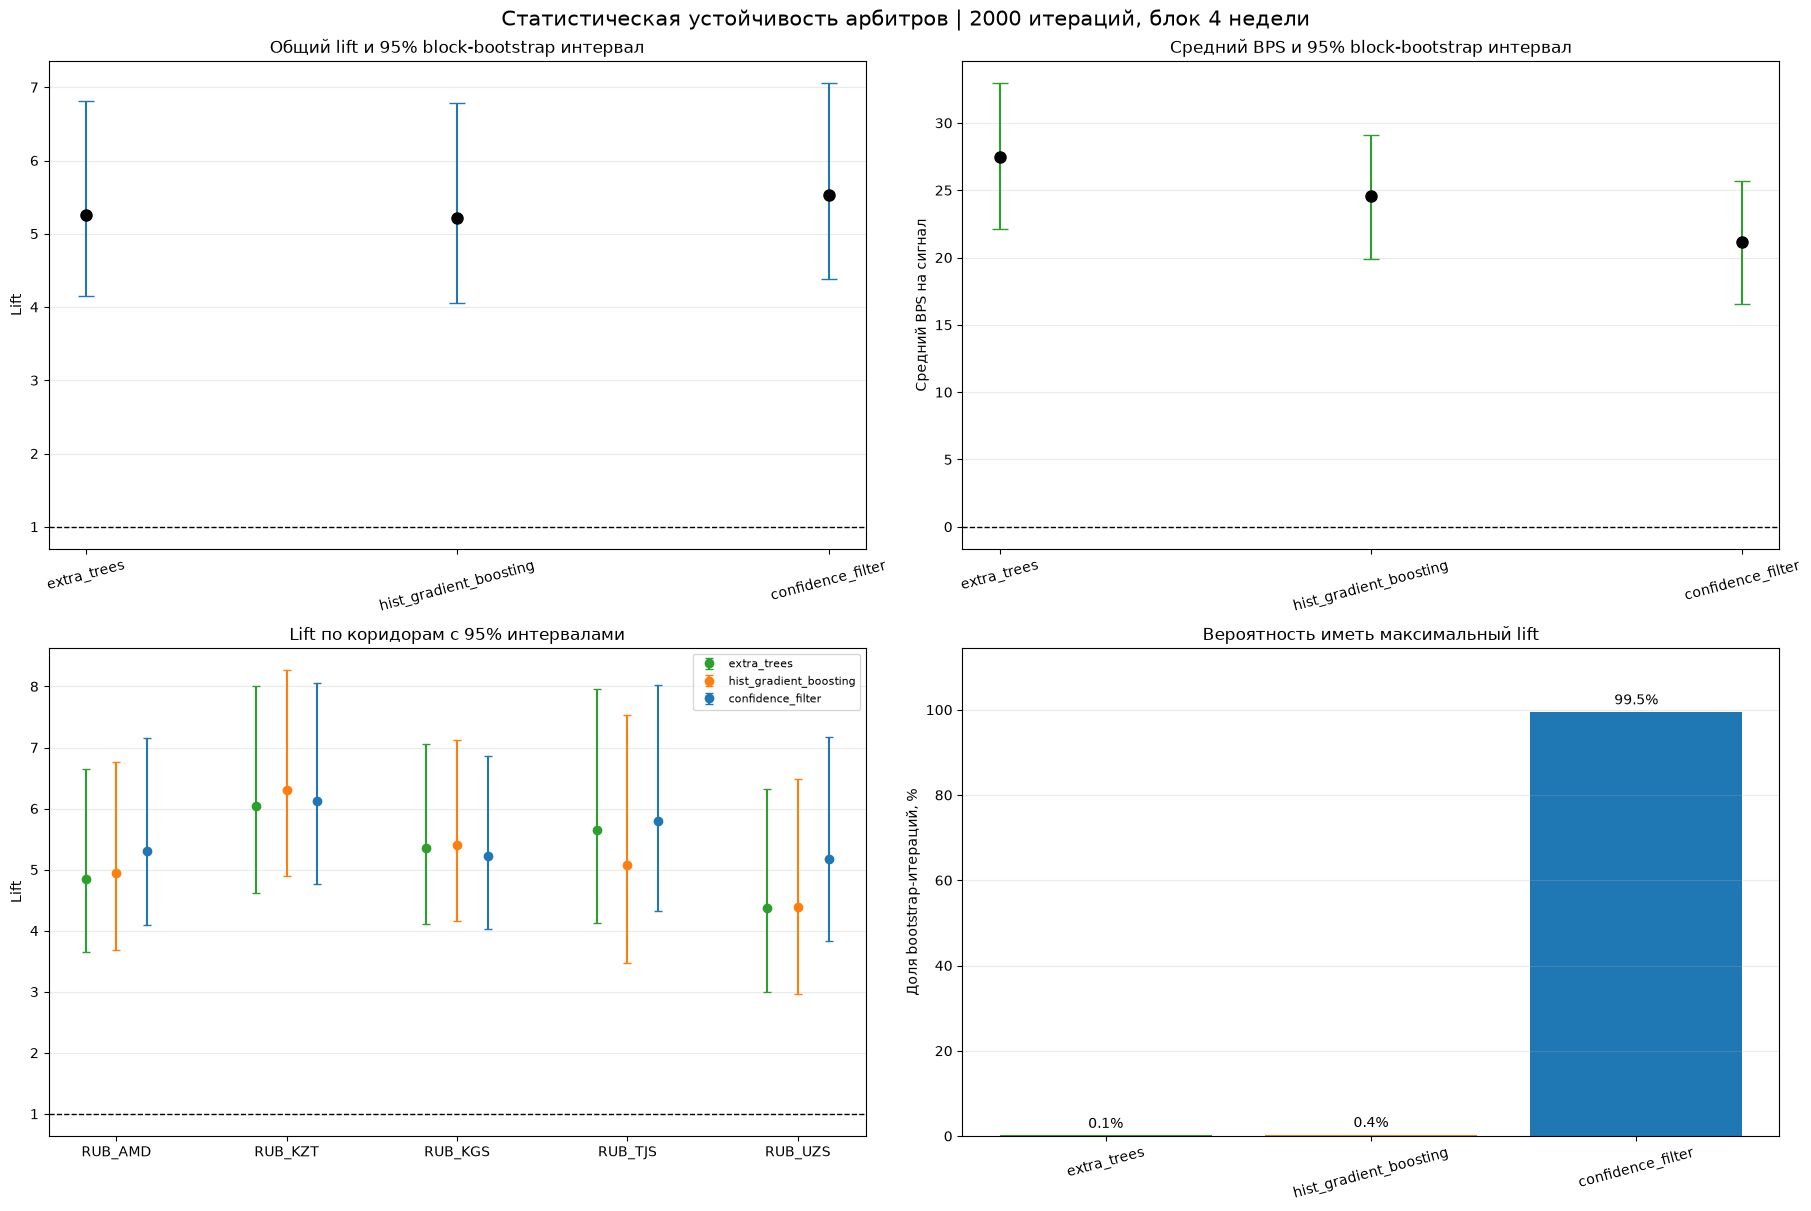

In [30]:
bootstrap_colors = {
    'extra_trees': 'tab:green',
    'hist_gradient_boosting': 'tab:orange',
    'confidence_filter': 'tab:blue',
}
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

overall_plot = arbiter_bootstrap_overall.set_index('arbiter').loc[list(SELECTED_ARBITERS)]
positions = np.arange(len(overall_plot))
lift_yerr = np.vstack([
    overall_plot['lift'] - overall_plot['lift_ci_low'],
    overall_plot['lift_ci_high'] - overall_plot['lift'],
])
axes[0, 0].errorbar(
    positions, overall_plot['lift'], yerr=lift_yerr, fmt='o', capsize=6,
    markersize=8, color='black', ecolor='tab:blue',
)
axes[0, 0].set_xticks(positions, overall_plot.index, rotation=15)
axes[0, 0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Общий lift и 95% block-bootstrap интервал')
axes[0, 0].set_ylabel('Lift')
axes[0, 0].grid(axis='y', alpha=0.25)

bps_yerr = np.vstack([
    overall_plot['mean_benefit_bps'] - overall_plot['mean_bps_ci_low'],
    overall_plot['mean_bps_ci_high'] - overall_plot['mean_benefit_bps'],
])
axes[0, 1].errorbar(
    positions, overall_plot['mean_benefit_bps'], yerr=bps_yerr,
    fmt='o', capsize=6, markersize=8, color='black', ecolor='tab:green',
)
axes[0, 1].set_xticks(positions, overall_plot.index, rotation=15)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('Средний BPS и 95% block-bootstrap интервал')
axes[0, 1].set_ylabel('Средний BPS на сигнал')
axes[0, 1].grid(axis='y', alpha=0.25)

currency_bootstrap = arbiter_bootstrap_summary.loc[
    arbiter_bootstrap_summary['currency'].ne('ALL')
]
currency_positions = np.arange(len(currency_order))
for offset_index, arbiter_name in enumerate(SELECTED_ARBITERS):
    data = (
        currency_bootstrap.loc[currency_bootstrap['arbiter'].eq(arbiter_name)]
        .set_index('currency').reindex(currency_order)
    )
    offset = (offset_index - 1) * 0.18
    yerr = np.vstack([
        data['lift'] - data['lift_ci_low'],
        data['lift_ci_high'] - data['lift'],
    ])
    axes[1, 0].errorbar(
        currency_positions + offset, data['lift'], yerr=yerr,
        fmt='o', capsize=3, label=arbiter_name,
        color=bootstrap_colors[arbiter_name],
    )
axes[1, 0].set_xticks(currency_positions, [f'RUB_{x}' for x in currency_order])
axes[1, 0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Lift по коридорам с 95% интервалами')
axes[1, 0].set_ylabel('Lift')
axes[1, 0].grid(axis='y', alpha=0.25)
axes[1, 0].legend(fontsize=8)

best_plot = overall_plot['probability_best_lift'] * 100
bars = axes[1, 1].bar(
    best_plot.index, best_plot,
    color=[bootstrap_colors[name] for name in best_plot.index],
)
axes[1, 1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1, 1].set_ylim(0, max(100, best_plot.max() * 1.15))
axes[1, 1].set_title('Вероятность иметь максимальный lift')
axes[1, 1].set_ylabel('Доля bootstrap-итераций, %')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(axis='y', alpha=0.25)

fig.suptitle(
    f'Статистическая устойчивость арбитров | {BOOTSTRAP_REPEATS} итераций, '
    f'блок {BOOTSTRAP_BLOCK_WEEKS} недели',
    fontsize=15,
)
fig.savefig(
    ARBITER_PLOT_DIR / 'selected_arbiters_bootstrap_stability.png',
    dpi=180, bbox_inches='tight',
)
plt.show()


## 8. Опциональное сохранение production state

На реальном сервисе состояние сохраняется после успешного обновления и загружается при старте процесса. В notebook запись намеренно выключена: раскомментируйте только если нужен локальный snapshot.

In [31]:
# STATE_PATH = PROJECT_ROOT / 'models' / 'engine_states.joblib'
# save_engine_states(replay.states, STATE_PATH)

## 9. Визуализации

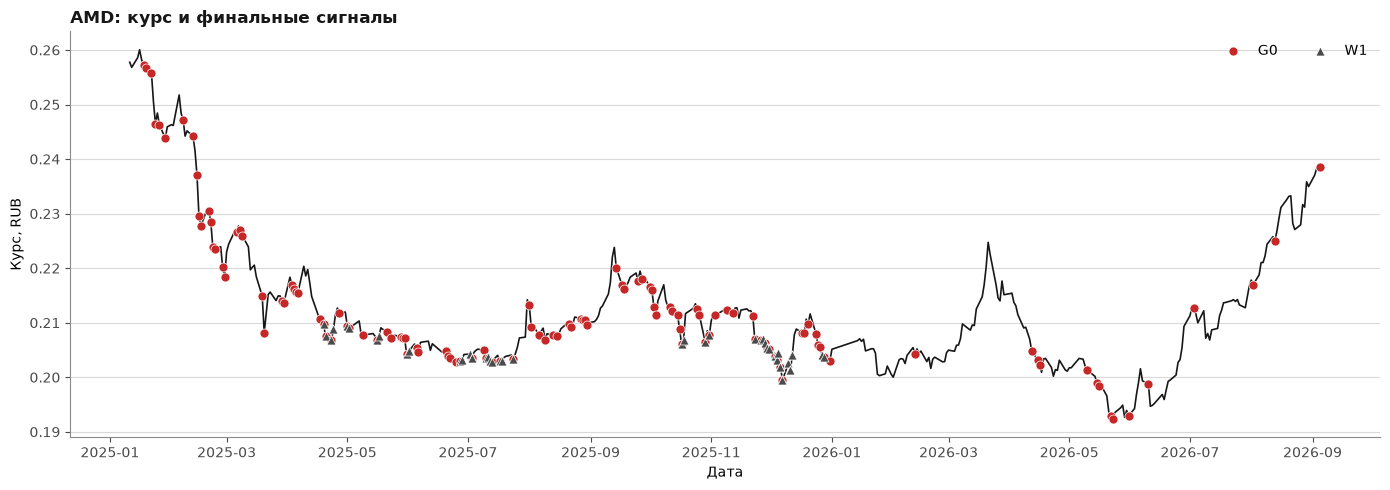

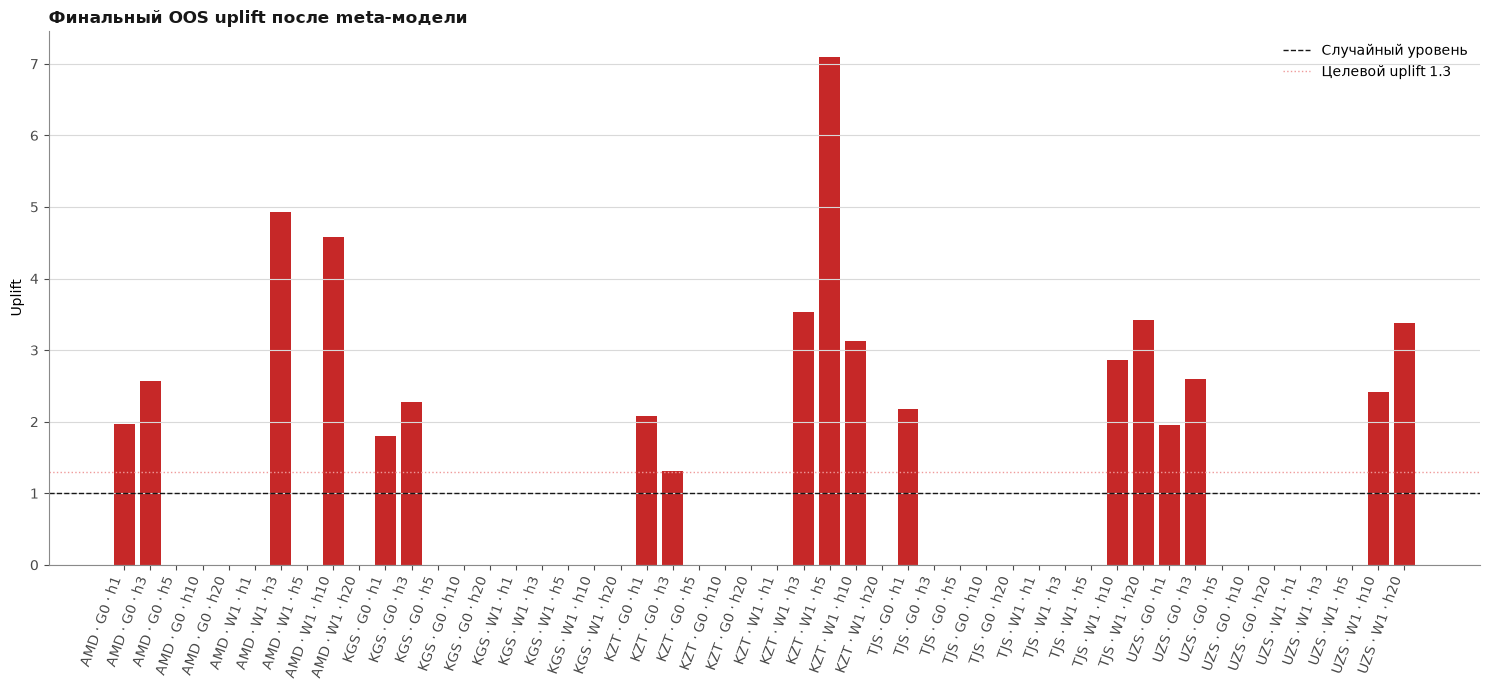

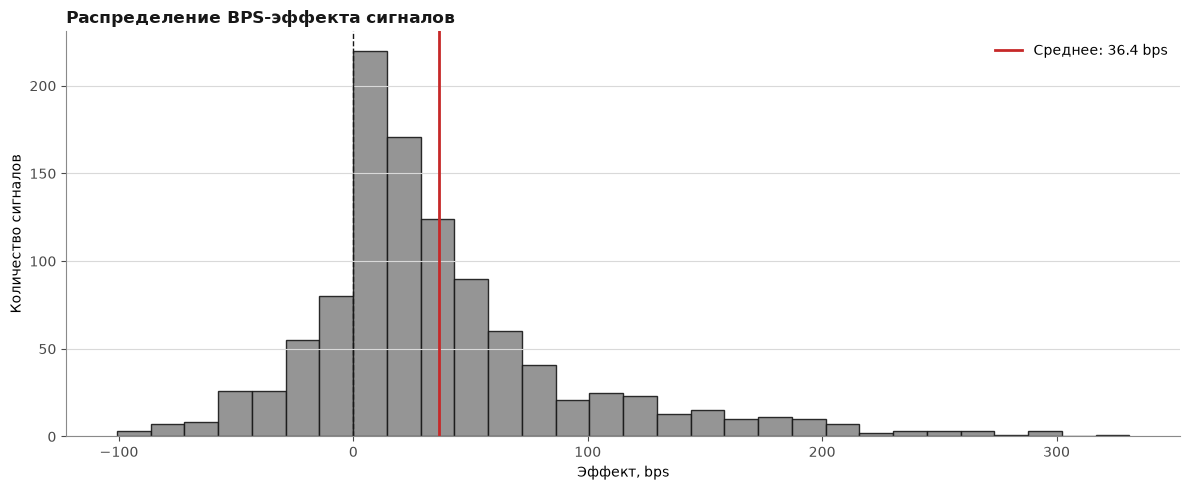

In [32]:
# Отдельная секция графика конечных сигналов после метамодели.
import matplotlib.pyplot as plt
PRESENTATION_CURRENCY = 'AMD'
plot_signal_series(
    scoring_data,
    final_signal_stream,
    currency=PRESENTATION_CURRENCY,
    start_date="2025-01-01",
)
plt.tight_layout()
plt.show()

plot_oos_uplift(
    signal_backtest_summary.loc[signal_backtest_summary['scope'].eq('currency+horizon+target_family')],
    uplift_column='lift',
    title='Финальный OOS uplift после meta-модели',
)
plt.tight_layout()
plt.show()

signal_benefit = signal_backtest_rows.loc[signal_backtest_rows['signal']].copy()
if 'benefit_bps' in signal_benefit.columns:
    plot_benefit_distribution(signal_benefit)
    plt.tight_layout()
    plt.show()